In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.functional import accuracy, precision, recall, f1_score

import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

import time
import pandas
import os
from prettytable import PrettyTable

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

In [3]:
#Set device to GPU_indx if GPU is avaliable
GPU_indx = 0
device = torch.device(GPU_indx if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [5]:
# !pip install torchmetrics

In [6]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from torchmetrics.functional import accuracy, precision, recall, f1_score

# import torchvision.transforms as transforms

# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import clear_output

# import time
# import pandas
# import os
# from prettytable import PrettyTable

In [7]:
# #Set device to GPU_indx if GPU is avaliable
# GPU_indx = 0
# device = torch.device(GPU_indx if torch.cuda.is_available() else 'cpu')
# print(device)

In [8]:
# class Data(Dataset):
    # def __init__(self, train = True):
    #     SolarData = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/1. Feature Generation/SolarGeneration.csv', header=None)
    #     SolarData = np.array(SolarData) # (1000, 24)
    #     SolarData = SolarData.astype(float)

    #     WindData = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/1. Feature Generation/Practical_WindGeneration_HighVar.csv', header=None)
    #     WindData = np.array(WindData) # (1000, 24)
    #     WindData = WindData.astype(float)

    #     OnOff = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/DL-TESS-SUC118 (Solar & Wind)/Labels/MILP_Optimum_OnOff_1S.csv', header=None)
    #     OnOff = np.array(OnOff)           # (54000, 24)
    #     OnOff = OnOff.reshape(1000,54*24)  # (1000, 1296)

    #     Arc = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/DL-TESS-SUC118 (Solar & Wind)/Labels/MILP_Optimum_Arc_1S.csv', header=None)
    #     Arc = np.array(Arc)           # (23000, 30)
    #     Arc = Arc.reshape(1000,30*23)  # (1000, 690)

    #     ESC_OnOff = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/DL-TESS-SUC118 (Solar & Wind)/Labels/MILP_Optimum_ESCOnOff_1S.csv', header=None)
    #     ESC_OnOff = np.array(ESC_OnOff) # (1000, 23)

    #     ESD_OnOff = pandas.read_csv('/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/6.Codes/DL-TESS-SUC118 (Solar & Wind)/Labels/MILP_Optimum_ESDOnOff_1S.csv', header=None)
    #     ESD_OnOff = np.array(ESD_OnOff) # (1000, 23)

    #     Labels = np.concatenate((OnOff, Arc, ESC_OnOff, ESD_OnOff), axis=1)

    #     if train:
    #         #trainloader
    #         # self.features = torch.FloatTensor(SolarData[200:,:].T)
    #         self.features = torch.cat((
    #             torch.FloatTensor(SolarData[200:,:].T).unsqueeze(0),
    #             torch.FloatTensor(WindData[200:,:].T).unsqueeze(0)
    #             ), 0) # (2, 24, 800)
    #         self.labels = torch.FloatTensor(Labels[200:,:].T)

    #         # OnOff.min() = -7.6100e-13
    #         # OnOff.max() = 1
    #         # round off OnOff to be either 0 or 1
    #         self.labels = torch.round(self.labels)
    #     else:
    #         #testloader
    #         # self.features = torch.FloatTensor(SolarData[:200,:].T)
    #         self.features = torch.cat((
    #             torch.FloatTensor(SolarData[:200,:].T).unsqueeze(0),
    #             torch.FloatTensor(WindData[:200,:].T).unsqueeze(0)
    #             ), 0) # (2, 24, 200)
    #         self.labels = torch.FloatTensor(Labels[:200,:].T)

    #         # OnOff.min() = -7.6100e-13
    #         # OnOff.max() = 1
    #         # round off OnOff to be either 0 or 1
    #         self.labels = torch.round(self.labels)

    # def __len__(self):
    #     return self.features.shape[-1]

    # def __getitem__(self, idx):
    #     if torch.is_tensor(idx):
    #         idx = idx.tolist()
    #     # features = np.expand_dims(self.features[:, idx], 0)
    #     features = self.features[:, :, idx]
    #     labels = self.labels[:, idx]
    #     # features = np.swapaxes(features, 0, 1)  # for LSTM
    #     return features, labels

In [3]:
base = r"D:\Savini\Wen Codes\savini_new_results"
levels = [95, 90, 80, 70, 60]

features_all = []
labels_all   = []

for lv in levels:
    feat_path = fr"{base}\CC_{lv}\Features_CC.csv"
    lab_path  = fr"{base}\CC_{lv}\Labels_CC.csv"

    dfF = pd.read_csv(feat_path)
    dfL = pd.read_csv(lab_path)

    # safety: rows must match so feature row i == label row i
    if len(dfF) != len(dfL):
        raise ValueError(f"Row mismatch in CC_{lv}: Features={len(dfF)} Labels={len(dfL)}")

    features_all.append(dfF)
    labels_all.append(dfL)

# concatenate DOWNWARDS
Features_all = pd.concat(features_all, ignore_index=True)
Labels_all   = pd.concat(labels_all,  ignore_index=True)

# save final 2500-sample files
Features_all.to_csv(fr"{base}\Features_CC_ALL.csv", index=False)
Labels_all.to_csv(fr"{base}\Labels_CC_ALL.csv", index=False)

print("Done!")
print("Features:", Features_all.shape)
print("Labels:  ", Labels_all.shape)

# L_df = pd.read_csv(r"D:\Savini\Wen Codes\savini_results\Labels_CC_ALL.csv", header=0)
# L_df = L_df.drop(columns=["Confidence_Level","nbES"])
# print(L_df.columns[:5])          # should start with GOn_g0_t0 ...
# print(L_df.columns[1295])        # should be GOn_g53_t23
# print(L_df.columns[1296])        # should be CC_sc0

Done!
Features: (2500, 4802)
Labels:   (2500, 8310)


In [4]:
# class Data(Dataset):
#     def __init__(self, train=True, seed = 0):

#         # ---- read features (has headers) ----
#         FeaturesData = pd.read_csv(r"D:\Savini\Wen Codes\savini_new_results\Features_CC_ALL.csv", header=0)
#         F = FeaturesData.to_numpy(dtype=np.float32)          # (N, D)
#         N = F.shape[0]

#         conf = F[:, 0]                              # (N,)
#         nbes = F[:, 1]                              # (N,)

#         solar_flat = F[:, 2:2+2400]                 # (N, 2400) 100*24
#         wind_flat  = F[:, 2+2400 : ]                # (N, 2400)

#         solar = solar_flat.reshape(N, 100, 24)      # (N, 100, 24)
#         wind  = wind_flat.reshape(N, 100, 24)       # (N, 100, 24)

#         nBES = np.repeat(nbes[:, None, None], 100, axis=1)
#         nBES = np.repeat(nBES, 24, axis=2)    # (N, 100, 24)

#         confidence = np.repeat(conf[:, None, None], 100, axis=1)
#         confidence = np.repeat(confidence, 24, axis=2)    # (N, 100, 24)

#         X = np.stack([wind, solar, nBES, confidence], axis=1)  # (N, 4, 100, 24)
#         X = np.transpose(X, (1, 2, 3, 0))  # (4,100,24,N)
#         X = torch.FloatTensor(X)

#         # ---- read labels ----
#         # If labels.csv has headers, use header=0. If not, change to header=None.
#         L_df = pd.read_csv(r"D:\Savini\Wen Codes\savini_new_results\Labels_CC_ALL.csv", header=0)  
#         if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
#             L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
#         else:
#             # fallback: assume first 2 columns are [Confidence_Level, nbES]
#             L_df = L_df.iloc[:, 2:]
        
#         L = L_df.to_numpy(dtype=np.float32)
#         if L.shape[0] != N:
#             raise ValueError(f"Labels rows ({L.shape[0]}) must match features rows ({N}).")
#         L = torch.FloatTensor(L).T   # (Y, N)

#         # ---- random split ----
#         rng = np.random.RandomState(seed)
#         idx = rng.permutation(N)
#         test_idx  = idx[:500]
#         train_idx = idx[500:]

#         nbes_t = torch.FloatTensor(nbes)   # (N,)
#         conf_t = torch.FloatTensor(conf)   # (N,)

#         if train:
#             self.nbes = nbes_t[train_idx].long()  # (Ntrain,)
#             self.conf = conf_t[train_idx]
#         else:
#             self.nbes = nbes_t[test_idx].long()   # (Ntest,)
#             self.conf = conf_t[test_idx]

#         # ---- split ----
#         if train:
#             self.features = X[:, :, :, train_idx]          # (4, 100, 24, train)
#             self.labels   = L[:, train_idx]          # (Y, train)
#             self.labels = torch.round(self.labels)
#         else:
#             self.features = X[:, :, :, test_idx]          # (4, 100, 24, test)
#             self.labels   = L[:, test_idx]          # (Y, test)
#             self.labels = torch.round(self.labels)

#     def __len__(self):
#         return self.features.shape[-1]

#     def __getitem__(self, idx):
#         if torch.is_tensor(idx):
#             idx = idx.tolist()
#         return self.features[:, :, :, idx], self.labels[:, idx]

class Data(Dataset):
    def __init__(self, split="train", seed=0):

        # ---- read features ----
        FeaturesData = pd.read_csv(
            r"D:\Savini\Wen Codes\savini_new_results\Features_CC_ALL.csv",
            header=0
        )

        F = FeaturesData.to_numpy(dtype=np.float32)
        N = F.shape[0]

        conf = F[:, 0]       # Confidence_Level
        nbes = F[:, 1]       # nbES

        solar_flat = F[:, 2:2+2400]
        wind_flat  = F[:, 2+2400:]

        solar = solar_flat.reshape(N, 100, 24)
        wind  = wind_flat.reshape(N, 100, 24)

        nBES = np.repeat(nbes[:, None, None], 100, axis=1)
        nBES = np.repeat(nBES, 24, axis=2)

        confidence = np.repeat(conf[:, None, None], 100, axis=1)
        confidence = np.repeat(confidence, 24, axis=2)

        X = np.stack([wind, solar, nBES, confidence], axis=1)  # (N, 4, 100, 24)
        X = np.transpose(X, (1, 2, 3, 0))                     # (4, 100, 24, N)
        X = torch.FloatTensor(X)

        # ---- read labels ----
        L_df = pd.read_csv(
            r"D:\Savini\Wen Codes\savini_new_results\Labels_CC_ALL.csv",
            header=0
        )

        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        else:
            L_df = L_df.iloc[:, 2:]

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[0] != N:
            raise ValueError(f"Labels rows ({L.shape[0]}) must match features rows ({N}).")

        L = torch.FloatTensor(L).T   # (Y, N)

        # ---- stratified 70/15/15 split ----
        all_idx = np.arange(N)

        # stratify by both confidence level and nbES
        stratify_labels = np.array([
            f"{int(c)}_{int(n)}" for c, n in zip(conf, nbes)
        ])

        train_idx, temp_idx = train_test_split(
            all_idx,
            test_size=0.30,
            random_state=seed,
            shuffle=True,
            stratify=stratify_labels
        )

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=seed,
            shuffle=True,
            stratify=stratify_labels[temp_idx]
        )

        split = split.lower()

        if split == "train":
            selected_idx = train_idx
        elif split in ["val", "valid", "validation"]:
            selected_idx = val_idx
        elif split == "test":
            selected_idx = test_idx
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")

        self.indices = selected_idx

        self.features = X[:, :, :, selected_idx]
        self.labels   = torch.round(L[:, selected_idx])

        nbes_t = torch.FloatTensor(nbes)
        conf_t = torch.FloatTensor(conf)

        self.nbes = nbes_t[selected_idx].long()
        self.conf = conf_t[selected_idx]

    def __len__(self):
        return self.features.shape[-1]

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        return self.features[:, :, :, idx], self.labels[:, idx]

In [5]:
# CNN
# BS = 64
# #try 400 or 64

# trainset = Data(train=True, seed=0)
# trainloader = DataLoader(trainset, batch_size=BS, shuffle=True, num_workers=0)

# testset = Data(train=False, seed=0)
# testloader = DataLoader(testset, batch_size=BS, shuffle=False, num_workers=0)

# OUT_DIM = trainset.labels.shape[0]   # labels are (Y, N) so Y is dim 0
# print("OUT_DIM =", OUT_DIM)

# print(f"Trainset features size: {trainset.features.shape}")
# print(f"  Trainset labels size: {trainset.labels.shape}")
# print(f" Testset features size: {testset.features.shape}")
# print(f"   Testset labels size: {testset.labels.shape}")

# features, labels = next(iter(trainloader))
# print(features.shape)
# print(labels.shape)

# y_train = torch.as_tensor(trainset.labels).T.float()

BS = 64

trainset = Data(split="train", seed=0)
valset   = Data(split="val", seed=0)
testset  = Data(split="test", seed=0)

trainloader = DataLoader(trainset, batch_size=BS, shuffle=True,  num_workers=0)
valloader   = DataLoader(valset,   batch_size=BS, shuffle=False, num_workers=0)
testloader  = DataLoader(testset,  batch_size=BS, shuffle=False, num_workers=0)

OUT_DIM = trainset.labels.shape[0]

print("OUT_DIM =", OUT_DIM)

print(f"Trainset features size: {trainset.features.shape}")
print(f"Trainset labels size:   {trainset.labels.shape}")

print(f"Valset features size:   {valset.features.shape}")
print(f"Valset labels size:     {valset.labels.shape}")

print(f"Testset features size:  {testset.features.shape}")
print(f"Testset labels size:    {testset.labels.shape}")

features, labels = next(iter(trainloader))
print("Batch features:", features.shape)
print("Batch labels:", labels.shape)

OUT_DIM = 8308
Trainset features size: torch.Size([4, 100, 24, 1750])
Trainset labels size:   torch.Size([8308, 1750])
Valset features size:   torch.Size([4, 100, 24, 375])
Valset labels size:     torch.Size([8308, 375])
Testset features size:  torch.Size([4, 100, 24, 375])
Testset labels size:    torch.Size([8308, 375])
Batch features: torch.Size([64, 4, 100, 24])
Batch labels: torch.Size([64, 8308])


In [12]:
# class CNN(nn.Module):
#     def __init__(self):
#         super(CNN, self).__init__()
#         self.conv1 = nn.Conv1d(2, 256, kernel_size=5,  stride=1, padding=0)
#         self.conv2 = nn.Conv1d(256, 256, kernel_size=5,  stride=1, padding=0)
#         self.conv3 = nn.Conv1d(256, 8, kernel_size=5,  stride=1, padding=0)
#         self.conv4 = nn.Conv1d(8, 64, kernel_size=5,  stride=1, padding=0)
#         self.conv5 = nn.Conv1d(64, 32, kernel_size=3,  stride=1, padding=0)
#         self.linear1 = nn.Linear(192, self.output_dim())
#     def forward(self, x):
#         # (BS, C, 24)
#         x = F.relu( self.conv1(x) )
#         x = F.relu( self.conv2(x) )
#         x = F.relu( self.conv3(x) )
#         x = F.relu( self.conv4(x) )
#         x = F.relu( self.conv5(x) )
#         x = x.view(x.shape[0], -1)
#         x = self.linear1(x) # (BS, 2032)
#         x = torch.sigmoid(x)
#         return x
#     def output_dim(self):
#         return labels.shape[1]

In [6]:
class CNN(nn.Module):
    def __init__(self, out_dim = 8308, in_ch=4):
        super().__init__()

        # Assumption: conv_1_kernel_num = 32
        self.conv1 = nn.Conv2d(in_ch, 32, kernel_size=(3, 5), padding=(1, 2))
        self.conv2 = nn.Conv2d(32,   32, kernel_size=(3, 3), padding=(1, 1))
        self.conv3 = nn.Conv2d(32,   32, kernel_size=(3, 3), padding=(1, 1))
        # self.drop2d = nn.Dropout2d(0.1)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        # self.drop   = nn.Dropout(0.3)
        self.gap  = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(32, out_dim)

    def forward(self, x):
        # x: (BS, 4, 100, 24)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        # x = self.drop2d(x)
        x = self.gap(x).flatten(1)   # (BS, 32)
        # x = self.drop(x)
        x = self.fc(x)               # (BS, out_dim)
        x = torch.sigmoid(x)
        return x
    
# class CNN(nn.Module):
#     def __init__(self, in_ch=4):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_ch, 32, kernel_size=(3,5), padding=(1,2))
#         self.conv2 = nn.Conv2d(32,   64, kernel_size=(3,5), padding=(1,2))
#         self.pool  = nn.MaxPool2d(kernel_size=(2,2))
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=(3,3), padding=(1,1))
#         self.gap   = nn.AdaptiveAvgPool2d((1,1))
#         self.fc    = nn.Linear(128, OUT_DIM)

#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         x = self.pool(x)
#         x = F.relu(self.conv3(x))
#         x = self.gap(x).squeeze(-1).squeeze(-1)
#         x = self.fc(x)          # logits
#         return x          

In [14]:
# Train for 1 epoch
# def train_for_1(net, device, loader, optimizer, loss_fun):
#     epoch_loss = 0
#     net.train()
#     for i, (x, y) in enumerate(loader):
#         x = x.to(device)        # (BS, 2, 24)
#         y = y.to(device)        # (BS)
#         fx = net(x)             # forward pass (BS, 2032)
#         loss = loss_fun(fx, y)  # calculate loss
#         optimizer.zero_grad()   # zero grad
#         loss.backward()         # BP
#         optimizer.step()        # step
#         epoch_loss += loss.item()
#     epoch_loss /=  len(loader)
#     return epoch_loss           # return the average loss from the current epoch

# # evaluate for 1 epoch
# def evaluate_for_1(net, device, loader, loss_fun):
#     epoch_loss = 0
#     epoch_acc = 0
#     correct_predictions = 0
#     total_predictions = 0
#     net.eval()

#     with torch.no_grad():
#         for i, (x, y) in enumerate(loader):
#             x = x.to(device)
#             y = y.to(device)
#             fx = net(x)
#             loss = loss_fun(fx, y)  # calculate loss
#             # loss = loss_fun(fx, y.type(torch.LongTensor).to(device)) # needed when running on local pc

#             # fx = torch.round(fx)
#             fx = torch.where(fx >= 0.5, 1, 0) # threshold at 0.5

#             correct_predictions += (fx == y).sum().item()
#             total_predictions += y.shape[0]*y.shape[1]  # BS*2032

#             epoch_loss += loss.item()                     # cumulative loss

#     epoch_loss /=  len(loader)
#     epoch_acc = (correct_predictions/total_predictions)*100
#     return epoch_loss, epoch_acc

# # train for N epochs
# # def train_for_N(N, net, optimizer, loss_fun, device, trainloader, testloader, net_type=None, scheduler=None, log=True, LR_count=1, LR_index=0, layer_num=0, filter_num=0, neuron_num=0):
# def train_for_N(N, net, optimizer, loss_fun, device, trainloader, testloader):
#     training_loss_logger = []
#     testing_loss_logger = []
#     training_acc_logger = []
#     testing_acc_logger = []

#     Start_time = time.time()  # record the start time

#     for epoch in range(N):

#         # train for 1 epoch and get Training Loss
#         train_loss = train_for_1(net, device, trainloader, optimizer, loss_fun)

#         # evaluate for 1 epoch and get Training Acc. and Testing Acc.
#         _, train_acc = evaluate_for_1(net, device, trainloader, loss_fun)
#         test_loss, test_acc = evaluate_for_1(net, device, testloader, loss_fun)

#         training_loss_logger.append(train_loss)
#         testing_loss_logger.append(test_loss)
#         training_acc_logger.append(train_acc)
#         testing_acc_logger.append(test_acc)

#     End_time = time.time()

#     # return training_loss_logger, testing_loss_logger, training_acc_logger, testing_acc_logger, End_time-Start_time, std, mean
#     return training_loss_logger, testing_loss_logger, training_acc_logger, testing_acc_logger, End_time-Start_time

# def count_parameters(model):
#     table = PrettyTable(["Modules", "Parameters"])
#     total_params = 0
#     for name, parameter in model.named_parameters():
#         if not parameter.requires_grad: continue
#         params = parameter.numel()
#         table.add_row([name, params])
#         total_params+=params
#     print(table)
#     print(f"Total Trainable Params: {total_params}")

In [7]:
# Defines a function that trains your neural network net for one epoch (one full pass through loader).
def train_for_1(net, device, loader, optimizer, loss_fun):
    epoch_loss = 0
    net.train() #Puts the model into training mode

    # Loops through the DataLoader batch-by-batch.
    # Each x, y is a batch:
    for x, y in loader:
        x = x.to(device)       # (BS, 4, 100, 24)
        y = y.to(device).float()       # (BS, Y) 0/1

        # # Forward pass: feeds x through the network to get predictions fx.
        fx = net(x)                    # (BS, Y)
        # Computes the loss between predictions and true labels.
        loss = loss_fun(fx, y)

        # logits = net(x)               # (BS,Y) raw logits
        # loss = loss_fun(logits, y)
        # loss_pred = loss_fun(logits, y)
        # probs = torch.sigmoid(logits)
        # loss_mat = loss_fun(logits, y)  # (BS, Y)
        # loss = (loss_mat * valid_mask).sum() / (valid_mask.sum() * logits.size(0))

        # Clears old gradients from the previous batch.
        optimizer.zero_grad()

        # computes gradients of the loss w.r.t. all trainable parameters.
        loss.backward()

        # Updates the network weights using those gradients
        optimizer.step()

        # Adds the scalar loss value for this batch to the running total.
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_for_1(net, device, loader, loss_fun):
    
    #Accumulator for the sum of losses over all batches.
    epoch_loss = 0   

    #Accumulator for the sum of losses over all batches.
    correct = 0

    # Accumulator for how many individual output bits were predicted correctly (across all batches).
    total = 0

    # Puts the model into evaluation mode
    net.eval()

    # Disables gradient tracking to save memory and speed up evaluation (no backprop during eval)
    with torch.no_grad():
        # Loops through batches from the dataloader, x = batch of inputs, y = batch of labels.
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()   # (BS, Y)

            # Forward pass: model outputs predicted probabilities (since your model ends with sigmoid). Shape (BS, Y)
            fx = net(x)                # (BS, Y)

            # # Computes the batch loss comparing predictions fx to ground truth y
            loss = loss_fun(fx, y)

            # logits = net(x)                 # (BS,Y)
            # loss = loss_fun(logits, y)

            # probs = torch.sigmoid(logits)
            # pred = (probs >= 0.5).float()

            # correct += (pred == y).sum().item()
            # total += y.numel()


            # Converts probabilities into binary predictions using threshold 0.5: if fx >= 0.5 → 1, else → 0
            fx = torch.where(fx >= 0.5, 1, 0)     

            # Compares predicted bits to true bits elementwise:
            correct += (fx == y).sum().item()

            #  Adds the number of output bits evaluated in this batch: batch_size * number_of_outputs.
            total += y.shape[0]*y.shape[1]             # BS * Y

            # Adds this batch’s loss (scalar) into the running total loss.
            epoch_loss += loss.item()

    epoch_loss /= len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


            # correct += (pred == y).sum().item()
            # total += y.numel()
            # epoch_loss += loss.item()

    

# def train_for_N(N, net, optimizer, loss_fun, device, trainloader, testloader):
#     # Defines a function to train for N epochs, given the model, optimizer, loss function, device, and dataloaders.
#     training_loss_logger = []
#     testing_loss_logger = []
#     training_acc_logger = []
#     testing_acc_logger = []

#     Start_time = time.time()

#     for epoch in range(N):
#         # Runs one full training epoch over the training loader, returns the average training loss for that epoch.
#         train_loss = train_for_1(net, device, trainloader, optimizer, loss_fun)

#         # Evaluates the model on the training set (no gradient updates), returns (loss, acc).
#         _, train_acc = evaluate_for_1(net, device, trainloader, loss_fun)

#         # Evaluates the model on the training set (no gradient updates), returns (loss, acc).
#         test_loss, test_acc = evaluate_for_1(net, device, testloader, loss_fun)

#         print(f"Epoch {epoch+1:03d}/{N} | "
#               f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.2f}% | "
#               f"Test Loss: {test_loss:.6f} | Test Acc: {test_acc:.2f}%")
        
#         training_loss_logger.append(train_loss)
#         testing_loss_logger.append(test_loss)
#         training_acc_logger.append(train_acc)
#         testing_acc_logger.append(test_acc)

#     End_time = time.time()
#     return training_loss_logger, testing_loss_logger, training_acc_logger, testing_acc_logger, End_time-Start_time
import copy 
def train_for_N(N, net, optimizer, loss_fun, device, trainloader, valloader):
    training_loss_logger = []
    validation_loss_logger = []
    training_acc_logger = []
    validation_acc_logger = []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    start_time = time.time()

    for epoch in range(N):
        train_loss = train_for_1(net, device, trainloader, optimizer, loss_fun)

        _, train_acc = evaluate_for_1(net, device, trainloader, loss_fun)
        val_loss, val_acc = evaluate_for_1(net, device, valloader, loss_fun)

        print(f"Epoch {epoch+1:03d}/{N} | "
              f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.6f} | Val Acc: {val_acc:.2f}%")

        training_loss_logger.append(train_loss)
        validation_loss_logger.append(val_loss)
        training_acc_logger.append(train_acc)
        validation_acc_logger.append(val_acc)

        # Keep best validation model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(net.state_dict())

    end_time = time.time()

    # Load best validation model before final testing
    if best_state is not None:
        net.load_state_dict(best_state)
        print(f"\nLoaded best model from epoch {best_epoch} with Val Loss = {best_val_loss:.6f}")

    return (
        training_loss_logger,
        validation_loss_logger,
        training_acc_logger,
        validation_acc_logger,
        end_time - start_time
    )

def count_parameters(model):
    # Creates a pretty table with 2 columns: the parameter name (“Modules”) and how many numbers it contains (“Parameters”).
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0

    # Loops through every parameter tensor in the model. name is a string like "conv1.weight", "fc.bias", etc. parameter is the actual tensor (weights/biases).
    for name, parameter in model.named_parameters():
        # Skips parameters that are frozen (not trainable).requires_grad=False means they won’t be updated by backprop.
        if not parameter.requires_grad: continue

        #  Counts how many scalar values are in that tensor. Example: a weight tensor of shape (64, 32, 3, 3) has 64*32*3*3 numbers.
        params = parameter.numel()

        # Adds a row to the table showing the parameter name and its count.
        table.add_row([name, params])
        total_params+=params
    print(table)
    print(f"Total Trainable Params: {total_params}")

In [16]:
# def Predict(model, IndexOfTestScenarios = [0], is_test_set=True):
#     # Input:
#     #     IndexOfTestScenarios    List of indexes of test scenarios
#     # Output:
#     #     predictedOnOff    (S, 54, 24)
#     #     predictedArcs     (S, 23, 30)
#     #     predictedESC      (S, 1, 23)
#     #     predictedESD      (S, 1, 23)
#     #     predictionTimes   (S)

#     model.eval()

#     S = len(IndexOfTestScenarios) # number of test scenarios
#     predictedOnOffs = np.zeros((S,54,24))
#     predictedArcs = np.zeros((S,23,30))
#     predictedESC = np.zeros((S,1,23))
#     predictedESD = np.zeros((S,1,23))
#     predictionTimes = np.zeros((S))

#     for s in range(S):
#         ind = IndexOfTestScenarios[s] # Index of test scenario

#         if is_test_set:
#             # testset.features          (2, 24, 200)
#             # testset.features[:,:,ind] (2, 24, 1)
#             # (2, 24, 1) -> (2, 24) -> (1, 2, 24)
#             test_scenario = torch.unsqueeze(torch.squeeze(testset.features[:,:,ind]), 0).to(device)
#         else:
#             # test_scenario = torch.unsqueeze(torch.unsqueeze(trainset.features[:,ind], -1), 0).to(device)
#             test_scenario = torch.unsqueeze(torch.squeeze(trainset.features[:,:,ind]), 0).to(device)

#         start = time.time()

#         # predictedOnOff = torch.round(model(test_scenario)).detach().cpu().numpy().reshape(54,24)
#         prediction = (torch.where(model(test_scenario) >= 0.5, 1, 0)).detach().cpu().numpy() # (1, 2032)

#         end = time.time()

#         predictedOnOffs[s,:]  = prediction[0,:54*24].reshape(54,24)
#         predictedArcs[s,:]    = prediction[0,54*24:54*24+23*30].reshape(23,30)
#         predictedESC[s,:]     = prediction[0,54*24+23*30:54*24+23*30+23].reshape(1,23)
#         predictedESD[s,:]     = prediction[0,54*24+23*30+23:].reshape(1,23)

#         predictionTimes[s] = end - start
#     return predictedOnOffs, predictedArcs, predictedESC, predictedESD, predictionTimes

In [8]:
def Predict(model, IndexOfTestScenarios=[0], is_test_set=True):

    n_gen=54 
    T=24
    n_cc=100
    max_es=9
    es_T=24
    arc_A=30

    # Puts the model in evaluation mode
    model.eval()

    # Puts the model in evaluation mode
    S = len(IndexOfTestScenarios)


    gen_len = n_gen * T            # 1296
    cc_len  = n_cc                 # 100
    esc_len = es_T               # 23
    esd_len = es_T                 # 23
    arc_len = es_T * 30         # 690
    total_needed = gen_len + cc_len + max_es*(esc_len + esd_len + arc_len)  # 8020

    predGOn = np.zeros((S, n_gen, T))
    predCC  = np.zeros((S, n_cc))
    predESC = np.zeros((S, max_es, es_T))
    predESD = np.zeros((S, max_es, es_T))
    predARC = np.zeros((S, max_es, es_T, arc_A))
    predTimes = np.zeros((S))

    for s in range(S):
        ind = IndexOfTestScenarios[s]
        # Gets one sample from your dataset:
        # testset.features[:, :, :, ind] has shape (4,100,24)
        # squeeze removes any accidental extra dimension (sometimes indexing can produce (4,100,24,1))
        # unsqueeze(0) adds batch dimension → (1,4,100,24)
        if is_test_set:
            x = torch.unsqueeze(torch.squeeze(testset.features[:, :, :, ind]), 0).to(device)
        else:
            x = torch.unsqueeze(torch.squeeze(trainset.features[:, :, :, ind]), 0).to(device)

        start = time.time()

        # out = model(x)                    # (1, Y)
        # yhat = (out >= 0.5).float()       # (1, Y) in {0,1}
        # yhat = yhat.detach().cpu().numpy()[0]   # (Y,)

        # model(x) outputs probabilities (because your CNN ends with sigmoid)
        # threshold at 0.5 → convert to 0/1 predictions
        # detach() stops gradients
        # .cpu() moves to CPU
        # .numpy() converts to numpy array
        # Result shape: (1, Y) where Y should be 8020.
        yhat = (torch.where(model(x) >= 0.5, 1, 0)).detach().cpu().numpy()

        end = time.time()

        # ensure model output has enough columns.
        if yhat.shape[1] < total_needed:
            raise ValueError(f"Model out_dim={yhat.shape[1]} but need {total_needed}.")

        k = 0
       
        # 1) Generator schedules

        # batch has only one item. so since batch is the first dimension indexed to zero
        # reshapes into (54,24) generator schedule.
        predGOn[s] = yhat[0, k:k+gen_len].reshape(n_gen, T)
        # moves the pointer
        k += gen_len

        # 2) CC_sc
        # Next 100 values go into CC block
        predCC[s] = yhat[0, k:k+cc_len]
        # moves the pointer
        k += cc_len

        # 3) For each ES unit
        # So for one scenario s with 9 active ES: ES is a dimension
        # predESC[s, 0, :] = ESC for 1st ES (23 values)
        # predESC[s, 1, :] = ESC for 2nd ES
        # …
        # predESC[s, 8, :] = ESC for 9th ES
        for es in range(max_es):
            predESC[s, es] = yhat[0, k:k+esc_len]; k += esc_len
            predESD[s, es] = yhat[0, k:k+esd_len]; k += esd_len
            predARC[s, es] = yhat[0, k:k+arc_len].reshape(es_T, arc_A); k += arc_len

        predTimes[s] = end - start

        # print(predGOn[0,0,:])       # gen 0, 24 hours
        # print(predGOn[0,1,:])       # gen 1
        # print(predGOn[0].sum())     # total ONs in scenario 0

    return predGOn, predCC, predESC, predESD, predARC, predTimes

In [8]:
def extract_true_cc_from_dataset(dataset, IndexOfScenarios):
    gen_len = 54 * 24
    cc_len = 100

    # dataset.labels has shape (Y, N)
    trueCC = dataset.labels[gen_len:gen_len + cc_len, IndexOfScenarios].T
    trueCC = trueCC.detach().cpu().numpy() if hasattr(trueCC, "detach") else np.array(trueCC)

    return trueCC.astype(int)   # shape = (S, 100)

def extract_conf_from_dataset(dataset, IndexOfScenarios):
    conf = dataset.conf[IndexOfScenarios]
    conf = conf.detach().cpu().numpy() if hasattr(conf, "detach") else np.array(conf)
    return conf

def evaluate_cc_group(predCC, trueCC, conf_vals, target_conf):
    mask = np.isclose(conf_vals, target_conf)

    pred = predCC[mask].astype(int)
    true = trueCC[mask].astype(int)

    if len(pred) == 0:
        return None

    # element-wise accuracy over all 100 CC labels
    element_accuracy = np.mean(pred == true)

    # exact scenario match: whole 100-length vector matches exactly
    exact_match_accuracy = np.mean(np.all(pred == true, axis=1))

    # average number of mismatches per scenario
    avg_mismatch_per_case = np.mean(np.sum(np.abs(pred - true), axis=1))

    # confusion counts
    pred_flat = pred.reshape(-1)
    true_flat = true.reshape(-1)

    TP = np.sum((pred_flat == 1) & (true_flat == 1))
    TN = np.sum((pred_flat == 0) & (true_flat == 0))
    FP = np.sum((pred_flat == 1) & (true_flat == 0))
    FN = np.sum((pred_flat == 0) & (true_flat == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # average number of 1s in predicted and true CC vectors
    avg_predicted_ones = np.mean(np.sum(pred, axis=1))
    avg_true_ones = np.mean(np.sum(true, axis=1))

    return {
        "confidence": target_conf,
        "num_cases": len(pred),
        "element_accuracy": element_accuracy,
        "exact_match_accuracy": exact_match_accuracy,
        "avg_mismatch_per_case": avg_mismatch_per_case,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
        "avg_predicted_ones": avg_predicted_ones,
        "avg_true_ones": avg_true_ones
    }

In [9]:
def is_feasible_from_predicted_z(predicted_z, epsilon):
    """
    Check feasibility from predicted binary z values (violation indicators).

    Args:
        predicted_z (np.array): shape (nbScenarios, nbScenarios_chance)
            1 = satisfied (no violation), 0 = violated
        epsilon (float): maximum allowed violation rate
            e.g. epsilon = 0.05 means up to 5% violations allowed

    Returns:
        is_feasible_list (np.array): shape (nbScenarios,)
            1 if feasible, 0 otherwise
        violated_counts (np.array): shape (nbScenarios,)
            number of violations per scenario
        max_violations (int): maximum allowed number of violations
    """
    predicted_z = np.asarray(predicted_z)

    if predicted_z.ndim != 2:
        raise ValueError(f"predicted_z must be 2D, got shape {predicted_z.shape}")

    nbScenarios, nbScenarios_chance = predicted_z.shape

    # Calculate maximum allowed violations
    max_violations = int(epsilon * nbScenarios_chance)

    # Count how many 0s (violations) in each row (scenario)
    violated_counts = np.sum(predicted_z == 0, axis=1).astype(int)

    # Feasible if violations <= max_violations
    is_feasible_list = (violated_counts <= max_violations).astype(int)

    return is_feasible_list, violated_counts, max_violations

In [10]:
def violate_min_up_time_constraint(min_up_time, predicted_OnOff):
    T = 24
    AddTime = 11

    # a = predicted_OnOff[t-1] (previous hour)
    # b = predicted_OnOff[t] (current hour)
    # c = predicted_OnOff[k] (some future hour)

    # t is the possible startup time
    for t in range(1, T - min_up_time + AddTime):
        # k checks the next min_up_time hours after startup
        for k in range(t, min_up_time + t):
            a = predicted_OnOff[t - 1] if t <= 24 else 0
            b = predicted_OnOff[t] if t <= 23 else 0
            if (k >= 24):
                c = 0
            else:
                c = predicted_OnOff[k]
            # At startup time, we said -a + b = 1. a=0, b=1 at start up
            # Now, c is either 0 or 1:
            # If later hour k is ON → c = 1 → 1 - 1 = 0 → not > 0
            # If later hour k is OFF → c = 0 → 1 - 0 = 1 → > 0 → violation
            if (-a + b - c > 0):
                return True
    return False

def violate_min_down_time_constraint(min_down_time, predicted_OnOff):
    T = 24
    AddTime = 11
    for t in range(1, T - min_down_time + AddTime):
        for k in range(t, min_down_time + t):
            a = predicted_OnOff[t - 1] if t <= 24 else 0
            b = predicted_OnOff[t] if t <= 23 else 0
            if (k >= 24):
                c = 0
            else:
                c = predicted_OnOff[k]
            # So a - b is 1 only at shutdown. a=1, b=0 at shut down
            # If later hour k is OFF → c = 0 → 1 + 0 = 1 → not > 1 ✅ (good)
            # If later hour k is ON → c = 1 → 1 + 1 = 2 → > 1 → violation ❌
            if (a - b + c > 1):
                return True
    return False


def is_feasible_V1(predGOn_one, min_up_times, min_down_times, G=54, T=24):
    # predGOn_one: (54,24)
    predGOn_one = np.round(predGOn_one)

    # Creates an array length G filled with 1s:
    # feasibleG[g] = 1 means generator g is feasible
    # feasibleG[g] = 0 means generator g violates at least one constraint
    feasibleG = np.ones((G))
    startTime = time.time()

    for g in range(G):
        # Takes generator g’s predicted schedule predGOn_one[g, :] (length 24).
        # Checks minimum up time constraint using that generator’s min_up_times[g].
        if violate_min_up_time_constraint(min_up_times[g], predGOn_one[g, :]):
            feasibleG[g] = 0;
        if violate_min_down_time_constraint(min_down_times[g], predGOn_one[g, :]):
            feasibleG[g] = 0;

    feasCheckTime = time.time() - startTime
    return feasibleG, feasCheckTime

# def is_feasible_V1(predGOn_one, min_up_times, min_down_times, G, T):
# # Inputs:
# #     predictedOnOff    matrix [G,T]
#     min_up_times      vector [G]
#     min_down_times    vector [G]
#     G                 number of generators (54)
#     T                 number of hour (24)
#
#     SR                spinning reserve
#     load              load demand (24)
#
# Outputs:
    # NOPEEEEEE isFeasible      boolean vector {True = feasible; False = infeasible} [SCALAR]
#     feasibleG       boolean vector representing feasibility of OnOff for each generators {1 = feasible; 0 = infeasible} [G]
#     feasCheckTime   a scalar representing time required to perform feasibility check

    # predictedArc = np.round(predictedArc)
    # predictedOnOff = np.round(predictedOnOff)

    # # isFeasible = [True]
    # feasibleG = np.ones((G))

    # startTime = time.time()

    # for g in range(G):
    #     if (violate_min_up_time_constraint(min_up_times[g], predictedOnOff[g,:])):
    #         feasibleG[g] = 0;

    #     if (violate_min_down_time_constraint(min_down_times[g], predictedOnOff[g,:])):
    #         feasibleG[g] = 0;

    # endTime = time.time()
    # feasCheckTime = endTime - startTime

    # return feasibleG, feasCheckTime

In [11]:
def violate_singular_arc_constraint(arc_ts):
# Inputs:
#     arc_ts    arc at timespan ts    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
# ✅ [0,0,0,1,0,...,0] → sum = 1 → no violation
# ❌ [0,0,0,0,0,...,0] → sum = 0 → violation (chose none)
# ❌ [0,1,0,1,0,...,0] → sum = 2 → violation (chose two)
# At each time step, the ES must pick exactly one arc
    if (arc_ts.sum() != 1):
        return True
    return False


def violate_initial_TES_state_constraint(arc_ts_0):
# Inputs:
#     arc_ts_0    arc at timespan 0    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}

    # arc_ts_0[0] + arc_ts_0[1] + arc_ts_0[2] must equal 1
    # exactly one of those three must be 1
    # and (implicitly) the ES must not choose any other arc as the initial one 
    # (because if the “one” is somewhere else, these three sum to 0 → violation)
    if (arc_ts_0[0] + arc_ts_0[1] + arc_ts_0[2] != 1):
        return True
    return False

def violate_terminal_TES_state_constraint(arc_ts_23):
# Inputs:
#     arc_ts_23    arc at timespan 23    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
    # if (arc_ts_23[3] + arc_ts_23[7] + arc_ts_23[22] != 1):

    # Among indices 9, 19, 29, the sum must be exactly 1
    # → exactly one of those three must be 1 at the last time step.
    # Among indices 9, 19, 29, the sum must be exactly 1
    # → exactly one of those three must be 1 at the last time step.
    if (arc_ts_23[9] + arc_ts_23[19] + arc_ts_23[29] != 1):
        return True
    return False

def violate_TES_state_transition_constraint(arc_ts, arc_next_ts):
# Inputs:
#     arc_ts        arc at timespan ts      vector [9]
#     arc_next_ts   arc at timespan ts+1    vector [9]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
# The ES state at time ts (computed as a sum of some arc entries) must equal the ES state at time ts+1 (computed as a sum of some other arc entries).
    if (arc_ts[0] + arc_ts[15] + arc_ts[24] != arc_next_ts[0] + arc_next_ts[1] + arc_next_ts[2]):
        return True
    if (arc_ts[3] + arc_ts[7] + arc_ts[22] != arc_next_ts[3] + arc_next_ts[4] + arc_next_ts[5]):
        return True
    if (arc_ts[6] + arc_ts[5] + arc_ts[27] != arc_next_ts[6] + arc_next_ts[7] + arc_next_ts[8]):
        return True
    if (arc_ts[9] + arc_ts[19] + arc_ts[29] != arc_next_ts[9] + arc_next_ts[10] + arc_next_ts[11]):
        return True
    if (arc_ts[12] + arc_ts[1] + arc_ts[17] + arc_ts[21] != arc_next_ts[12] + arc_next_ts[13] + arc_next_ts[14] + arc_next_ts[15]):
        return True
    if (arc_ts[16] + arc_ts[11] + arc_ts[14] + arc_ts[28] != arc_next_ts[16] + arc_next_ts[17] + arc_next_ts[18] + arc_next_ts[19]):
        return True
    if (arc_ts[20] + arc_ts[2] + arc_ts[4] + arc_ts[13] + arc_ts[26] != arc_next_ts[20] + arc_next_ts[21] + arc_next_ts[22] + arc_next_ts[23] + arc_next_ts[24]):
        return True
    if (arc_ts[25] + arc_ts[8] + arc_ts[10] + arc_ts[18] + arc_ts[23] != arc_next_ts[25] + arc_next_ts[26] + arc_next_ts[27] + arc_next_ts[28] + arc_next_ts[29]):
        return True
    return False

def violate_charge_transfer_while_moving_constraint(feasible_arc_ts, ESCOnOff_ts, ESDOnOff_ts):
# Inputs:
#     feasible_arc_ts        arc at timespan ts      vector [30]
#     ESCOnOff_ts            charging status of ES at timespan ts [BINARY]
#     ESDOnOff_ts            discharging status of ES at timespan ts [BINARY]
# Outputs:
#     A boolean {True = violation, False = no violation}

    # In this model, that subset corresponds to “staying at a station” (not moving).
    # So if the ES is not moving, exactly one of these “stay” arcs should be active (sum = 1).
    # If the ES is moving, then none of these “stay” arcs are active (sum = 0)

    # Moving: is_staying = 0
    # If charging or discharging happens (sum=1), then 0 < 1 → violation ✅
    # Staying: is_staying = 1
    # If charging or discharging happens (sum=1), 1 < 1 false → no violation ✅
    # If no charge/discharge (sum=0), 1 < 0 false → no violation ✅
    # If both charge and discharge = 1 (sum=2), even staying gives 1 < 2 → violation ✅

    if (feasible_arc_ts[0] + feasible_arc_ts[3] + feasible_arc_ts[6] + feasible_arc_ts[9] + feasible_arc_ts[12] + feasible_arc_ts[16] + feasible_arc_ts[20] + feasible_arc_ts[25] < ESCOnOff_ts + ESDOnOff_ts):
        return True
    return False

def is_feasible_V2(predictedArc, predictedESCOnOff, predictedESDOnOff,
                   nbes_active, TS=24, arc_A=30):
    """
    predictedArc:       (max_es, TS, 30)
    predictedESCOnOff:  (max_es, TS)
    predictedESDOnOff:  (max_es, TS)
    nbes_active: int in [0..max_es]
    """

    predictedArc      = np.round(predictedArc)
    predictedESCOnOff = np.round(predictedESCOnOff)
    predictedESDOnOff = np.round(predictedESDOnOff)

    # K = number of ES that are active for this scenario.
    K = int(nbes_active)

    if K <= 0:
        arc_is_feasible = np.array([], dtype=bool)
        feasible_arc_TS = np.zeros((TS, 0))
        feasible_ESC_TS = np.zeros((TS, 0))
        feasible_ESD_TS = np.zeros((TS, 0))
        return arc_is_feasible, feasible_arc_TS, feasible_ESC_TS, feasible_ESD_TS, 0.0

    # Slices to only the first K ES units.
    # So now:
    # arc shape is (K, TS, 30)
    # esc shape is (K, TS)
    # esd shape is (K, TS)

    arc = predictedArc[:K]
    esc = predictedESCOnOff[:K]
    esd = predictedESDOnOff[:K]

    arc_is_feasible = np.ones((K,), dtype=bool)
    feasible_arc_TS = np.ones((TS, K))
    feasible_ESC_TS = np.ones((TS, K))
    feasible_ESD_TS = np.ones((TS, K))

    startTime = time.time()

    # Loop through each ES unit: k = 0..K-1
    for k in range(K):
        for ts in range(TS):
            # For each time step ts:
            # arc[k, ts, :] is a vector of length 30 
            if violate_singular_arc_constraint(arc[k, ts, :]):
                arc_is_feasible[k] = False
                feasible_arc_TS[ts, k] = 0

        # Checks arc choice at ts=0 must belong to allowed initial arcs (like 0/1/2).
        if violate_initial_TES_state_constraint(arc[k, 0, :]):
            arc_is_feasible[k] = False
            feasible_arc_TS[0, k] = 0

        # Checks whether the chosen arc at time ts correctly transitions to the next time ts+1.
        if violate_terminal_TES_state_constraint(arc[k, -1, :]):
            arc_is_feasible[k] = False
            feasible_arc_TS[-1, k] = 0

        # Checks whether the chosen arc at time ts correctly transitions to the next time ts+1.
        for ts in range(TS - 1):
            if violate_TES_state_transition_constraint(arc[k, ts, :], arc[k, ts + 1, :]):
                arc_is_feasible[k] = False
                feasible_arc_TS[ts, k] = 0
                feasible_arc_TS[ts + 1, k] = 0

        # the arc vector (30), ESC on/off at this ts, ESD on/off at this ts
        # That function returns True if charge/discharge happens when “moving”.
        for ts in range(TS):
            if feasible_arc_TS[ts, k] == 1:
                if violate_charge_transfer_while_moving_constraint(
                    arc[k, ts, :], esc[k, ts], esd[k, ts]
                ):
                    feasible_arc_TS[ts, k] = 0
                    feasible_ESC_TS[ts, k] = 0
                    feasible_ESD_TS[ts, k] = 0
            else:
                feasible_ESC_TS[ts, k] = 0
                feasible_ESD_TS[ts, k] = 0

    feasCheckTime = time.time() - startTime
    return arc_is_feasible, feasible_arc_TS, feasible_ESC_TS, feasible_ESD_TS, feasCheckTime

# def is_feasible_V2(predictedArc, predictedESCOnOff, predictedESDOnOff, K, TS):
# # Inputs:
# #     predictedArc        matrix [TS,30*K]
# #     predictedESCOnOff   matrix [K, TS]
# #     predictedESDOnOff   matrix [K, TS]
# #     K                   number of mobile energy storages
# #     TS                  number of timespan
# #
# # Outputs:
# #     isFeasible           boolean vector {True = feasible; False = infeasible} [K]
# #     feasible_arc_TS      binary vector representing feasibility of each ts {1 = feasible; 0 = infeasible} [TS,K]
# #     feasible_ESC_TS      binary vector representing feasibility of ESCOnOff at each ts {1 = feasible; 0 = infeasible} [TS,K]
# #     feasible_ESD_TS      binary vector representing feasibility of ESDOnOff at each ts {1 = feasible; 0 = infeasible} [TS,K]
# #     feasCheckTime        a scalar representing time required to perform feasibility check

#     predictedArc = np.round(predictedArc)
#     predictedESCOnOff = np.round(predictedESCOnOff)
#     predictedESDOnOff = np.round(predictedESDOnOff)

#     arc_is_feasible = [True]
#     feasible_arc_TS = np.ones((TS,K))
#     feasible_ESC_TS = np.ones((TS,K))
#     feasible_ESD_TS = np.ones((TS,K))

#     startTime = time.time()

#     # ES should take one (and only one) arc at any ts
#     for ts in range(TS):
#         if (violate_singular_arc_constraint(predictedArc[ts,:])):
#             arc_is_feasible[0] = False
#             feasible_arc_TS[ts,0] = 0

#     # ES should take arc 0 OR 1 OR 2 @ ts 0
#     if (violate_initial_TES_state_constraint(predictedArc[0,:])):
#         arc_is_feasible[0] = False
#         feasible_arc_TS[0,0] = 0

#     # ES should take arc 3 OR 7 OR 22 @ ts TS
#     if (violate_terminal_TES_state_constraint(predictedArc[-1,:])):
#         arc_is_feasible[0] = False
#         feasible_arc_TS[-1,0] = 0

#     # ES should arriving at station i could only depart from station i at the next ts
#     for ts in range(TS-1):
#         if (violate_TES_state_transition_constraint(predictedArc[ts,:], predictedArc[ts+1,:])):
#             arc_is_feasible[0] = False
#             feasible_arc_TS[ts,0] = 0
#             feasible_arc_TS[ts+1,0] = 0

#     # charge transfer only happens when ES stay at the same station
#     for k in range(K):
#         for ts in range(TS):
#             if (feasible_arc_TS[ts,k] == 1):
#                 if (violate_charge_transfer_while_moving_constraint(predictedArc[ts,30*k:30*k+30], predictedESCOnOff[k,ts], predictedESDOnOff[k,ts])):
#                     feasible_arc_TS[ts,k] = 0
#                     feasible_ESC_TS[ts,k] = 0
#                     feasible_ESD_TS[ts,k] = 0
#             else:
#                 feasible_ESC_TS[ts,k] = 0
#                 feasible_ESD_TS[ts,k] = 0


#     endTime = time.time()
#     feasCheckTime = endTime - startTime

#     return arc_is_feasible, feasible_arc_TS, feasible_ESC_TS, feasible_ESD_TS, feasCheckTime

In [12]:
# train
# lr=5e-3
# n_epochs = 100
# cnn = CNN().to(device)
# # pos_weight = pos_weight.to(device)
# # loss = nn.BCEWithLogitsLoss()
# loss = nn.BCELoss()
# opt = optim.Adam(cnn.parameters(), lr)

# train_losses, test_losses, train_accs, test_accs, _ = train_for_N(n_epochs, cnn, opt, loss, device, trainloader, testloader)

# train
lr = 5e-3
n_epochs = 100

cnn = CNN().to(device)

loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

train_losses, val_losses, train_accs, val_accs, _ = train_for_N(
    n_epochs,
    cnn,
    opt,
    loss,
    device,
    trainloader,
    valloader
)

# Final test evaluation only after training is finished
test_loss, test_acc = evaluate_for_1(cnn, device, testloader, loss)

print("\n================ FINAL TEST RESULT ================")
print(f"Test Loss: {test_loss:.6f}")
print(f"Test Acc:  {test_acc:.2f}%")
print("===================================================")

Epoch 001/100 | Train Loss: 1.500810 | Train Acc: 97.23% | Val Loss: 0.076996 | Val Acc: 97.25%
Epoch 002/100 | Train Loss: 0.061743 | Train Acc: 97.64% | Val Loss: 0.056396 | Val Acc: 97.66%
Epoch 003/100 | Train Loss: 0.056197 | Train Acc: 97.64% | Val Loss: 0.055243 | Val Acc: 97.66%
Epoch 004/100 | Train Loss: 0.055653 | Train Acc: 97.65% | Val Loss: 0.055077 | Val Acc: 97.67%
Epoch 005/100 | Train Loss: 0.055614 | Train Acc: 97.65% | Val Loss: 0.055001 | Val Acc: 97.66%
Epoch 006/100 | Train Loss: 0.055354 | Train Acc: 97.65% | Val Loss: 0.054974 | Val Acc: 97.67%
Epoch 007/100 | Train Loss: 0.055261 | Train Acc: 97.67% | Val Loss: 0.054420 | Val Acc: 97.68%
Epoch 008/100 | Train Loss: 0.054625 | Train Acc: 97.72% | Val Loss: 0.053159 | Val Acc: 97.74%
Epoch 009/100 | Train Loss: 0.051980 | Train Acc: 97.74% | Val Loss: 0.050575 | Val Acc: 97.75%
Epoch 010/100 | Train Loss: 0.048581 | Train Acc: 97.99% | Val Loss: 0.044973 | Val Acc: 98.00%
Epoch 011/100 | Train Loss: 0.044775 | T

In [15]:
# save_path = "D:\Savini\Wen Codes\savini_new_results\cnn_model_new_8308_outputs.pth"

# torch.save({
#     "model_state_dict": cnn.state_dict(),
#     "optimizer_state_dict": opt.state_dict(),
#     "n_epochs": n_epochs,
#     "learning_rate": lr,
#     "train_losses": train_losses,
#     "test_losses": test_losses,
#     "train_accs": train_accs,
#     "test_accs": test_accs,
# }, save_path)

# print(f"Model saved to {save_path}")

save_dir = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "cnn_model_best_val.pth")
excel_path = os.path.join(save_dir, "cnn_training_results.xlsx")
csv_path = os.path.join(save_dir, "cnn_training_results.csv")
txt_path = os.path.join(save_dir, "cnn_training_summary.txt")

# Find best validation epoch
best_epoch_idx = int(np.argmin(val_losses))
best_epoch = best_epoch_idx + 1

best_train_loss = train_losses[best_epoch_idx]
best_val_loss   = val_losses[best_epoch_idx]
best_train_acc  = train_accs[best_epoch_idx]
best_val_acc    = val_accs[best_epoch_idx]

# Save model checkpoint
torch.save({
    "model_state_dict": cnn.state_dict(),
    "optimizer_state_dict": opt.state_dict(),
    "n_epochs": n_epochs,
    "learning_rate": lr,

    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs,

    "best_epoch": best_epoch,
    "best_train_loss": best_train_loss,
    "best_val_loss": best_val_loss,
    "best_train_acc": best_train_acc,
    "best_val_acc": best_val_acc,

    "test_loss": test_loss,
    "test_acc": test_acc,
}, model_path)

# Save full epoch-by-epoch history
history_df = pd.DataFrame({
    "epoch": list(range(1, len(train_losses) + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accs,
    "val_accuracy": val_accs,
})

history_df["is_best_epoch"] = history_df["epoch"] == best_epoch
history_df["final_test_loss_using_best_model"] = test_loss
history_df["final_test_accuracy_using_best_model"] = test_acc

history_df.to_excel(excel_path, index=False)
history_df.to_csv(csv_path, index=False)

# Save readable summary using BEST model values
with open(txt_path, "w") as f:
    f.write("CNN Training Summary\n")
    f.write("====================\n\n")

    f.write(f"Number of epochs trained: {n_epochs}\n")
    f.write(f"Learning rate: {lr}\n\n")

    f.write("Best Validation Model\n")
    f.write("---------------------\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best model train loss: {best_train_loss:.6f}\n")
    f.write(f"Best model validation loss: {best_val_loss:.6f}\n")
    f.write(f"Best model train accuracy: {best_train_acc:.4f}\n")
    f.write(f"Best model validation accuracy: {best_val_acc:.4f}\n\n")

    f.write("Final Test Result Using Best Validation Model\n")
    f.write("---------------------------------------------\n")
    f.write(f"Test loss: {test_loss:.6f}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\n")

print("All files saved:")
print(model_path)
print(excel_path)
print(csv_path)
print(txt_path)

All files saved:
D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth
D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_training_results.xlsx
D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_training_results.csv
D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_training_summary.txt


In [16]:
# Recreate the same model architecture
# Recreate the same CNN architecture
cnn = CNN().to(device)

# Path to saved best-validation model
model_path = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth"

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device)

# Load model weights
cnn.load_state_dict(checkpoint["model_state_dict"])

# Put model in evaluation mode
cnn.eval()

print("CNN model loaded successfully")

CNN model loaded successfully


C:\Users\PC\AppData\Local\Temp\ipykernel_9236\4073832499.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


In [17]:
idx = 0

min_up_times    = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])
min_down_times  = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])

# y_true_flat shape should be (OUT_DIM,) or (54*24,) depending on your dataset
y_true_flat = trainset.labels[:, idx].cpu().numpy()

y_onoff_a = y_true_flat[:54*24].reshape(54, 24)        # generator-major
y_onoff_b = y_true_flat[:54*24].reshape(24, 54).T      # hour-major

feas_a, _ = is_feasible_V1(y_onoff_a, min_up_times, min_down_times, G=54, T=24)
feas_b, _ = is_feasible_V1(y_onoff_b, min_up_times, min_down_times, G=54, T=24)

print("GT feasible generators (reshape A):", feas_a.sum(), "/54")

GT feasible generators (reshape A): 48.0 /54


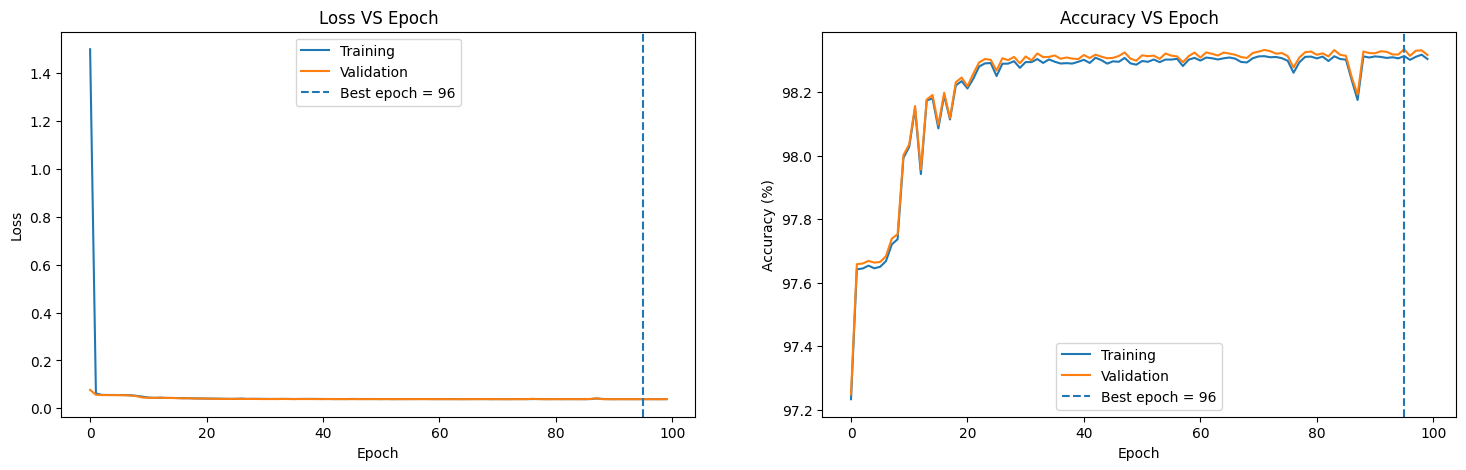

Best epoch: 96
Best validation loss: 0.03789193804065386
Best validation accuracy: 98.33580484673408
Final test loss using best validation model: 0.038591278716921806
Final test accuracy using best validation model: 98.32103996148291


In [ ]:
# # inspect loss and accuracy curve
# plt.figure(figsize = (25,5))
# plt.subplot(1, 4, 1)
# plt.plot(train_losses)
# plt.plot(test_losses)
# plt.title('Loss VS Epoch')
# plt.legend(['Training', 'Testing'])
# plt.xlabel('epoch')
# plt.ylabel('loss')

# plt.subplot(1, 4, 2)
# plt.plot(train_accs)
# plt.plot(test_accs)
# plt.title('Accuracy VS Epoch')
# plt.legend(['Training', 'Testing'])
# plt.xlabel('epoch')
# plt.ylabel('accuracy (%)')

# print('Testing accuracy: ', test_accs[-1])

# inspect loss and accuracy curve

best_epoch_idx = int(np.argmin(val_losses))   # 0-based index
best_epoch = best_epoch_idx + 1               # epoch number

plt.figure(figsize=(18, 5))

# -------------------------
# Loss curve
# -------------------------
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.plot(val_losses)
plt.axvline(best_epoch_idx, linestyle="--")
plt.title("Loss VS Epoch")
plt.legend(["Training", "Validation", f"Best epoch = {best_epoch}"])
plt.xlabel("Epoch")
plt.ylabel("Loss")

# -------------------------
# Accuracy curve
# -------------------------
plt.subplot(1, 2, 2)
plt.plot(train_accs)
plt.plot(val_accs)
plt.axvline(best_epoch_idx, linestyle="--")
plt.title("Accuracy VS Epoch")
plt.legend(["Training", "Validation", f"Best epoch = {best_epoch}"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()

print("Best epoch:", best_epoch)
print("Best validation loss:", val_losses[best_epoch_idx])
print("Best validation accuracy:", val_accs[best_epoch_idx])

print("Final test loss using best validation model:", test_loss)
print("Final test accuracy using best validation model:", test_acc)

In [ ]:
cnn = CNN().to(device)

# Path to saved best-validation model
model_path = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth"

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device)

# Load model weights
cnn.load_state_dict(checkpoint["model_state_dict"])

# Put model in evaluation mode
cnn.eval()

print("CNN model loaded successfully")
# -----------------------
# 1) Predict test scenarios (NEW Predict outputs)
# -----------------------
# You plan to evaluate up to 500 test samples.
# S_eval = 500
# IndexOfTestScenarios = np.arange(min(S_eval, len(testset)))  # safe if testset < 200
# You plan to evaluate up to 500 test samples.
IndexOfTestScenarios = np.arange(len(testset))
S = len(IndexOfTestScenarios)

# Runs your Predict() function on those test indices and returns:
# predGOn: (S, 54, 24)
# predCC: (S, 100)
# predESC: (S, 9, 23)
# predESD: (S, 9, 23)
# predARC: (S, 9, 23, 30)
# predictionTimes: (S,)
predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
    cnn, IndexOfTestScenarios, is_test_set=True
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# -----------------------
# 0) Get TRUE test labels from testset.labels
# -----------------------

def extract_true_structured_from_dataset(dataset, IndexOfTestScenarios):
    """
    dataset.labels shape: (8308, N)

    Label order:
    GOn -> CC -> for each ES:
        ESC, ESD, ARC
    """

    # Get labels for selected scenarios
    y_true_all = dataset.labels[:, IndexOfTestScenarios].T

    if hasattr(y_true_all, "detach"):
        y_true_all = y_true_all.detach().cpu().numpy()

    y_true_all = np.round(y_true_all).astype(int)

    S = y_true_all.shape[0]

    # Dimensions
    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    arc_A = 30

    gen_len = n_gen * T          # 54*24 = 1296
    cc_len = n_cc                # 100
    esc_len = T                  # 24
    esd_len = T                  # 24
    arc_len = T * arc_A          # 24*30 = 720

    total_needed = gen_len + cc_len + max_es * (esc_len + esd_len + arc_len)

    if y_true_all.shape[1] != total_needed:
        raise ValueError(
            f"Expected label length {total_needed}, got {y_true_all.shape[1]}"
        )

    trueGOn = np.zeros((S, n_gen, T), dtype=int)
    trueCC  = np.zeros((S, n_cc), dtype=int)
    trueESC = np.zeros((S, max_es, T), dtype=int)
    trueESD = np.zeros((S, max_es, T), dtype=int)
    trueARC = np.zeros((S, max_es, T, arc_A), dtype=int)

    for i in range(S):
        k = 0

        # 1) Generator on/off
        trueGOn[i] = y_true_all[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        # 2) Chance constraints
        trueCC[i] = y_true_all[i, k:k + cc_len]
        k += cc_len

        # 3) ES blocks: ESC, ESD, ARC for each ES
        for es in range(max_es):
            trueESC[i, es] = y_true_all[i, k:k + esc_len]
            k += esc_len

            trueESD[i, es] = y_true_all[i, k:k + esd_len]
            k += esd_len

            trueARC[i, es] = y_true_all[i, k:k + arc_len].reshape(T, arc_A)
            k += arc_len

    return trueGOn, trueCC, trueESC, trueESD, trueARC, y_true_all
trueGOn, trueCC, trueESC, trueESD, trueARC, y_true_all = extract_true_structured_from_dataset(
    testset,
    IndexOfTestScenarios
)
# -----------------------
# 1) Flatten everything into one binary vector
# -----------------------
y_true = np.concatenate([
    trueGOn.reshape(-1),
    trueCC.reshape(-1),
    trueESC.reshape(-1),
    trueESD.reshape(-1),
    trueARC.reshape(-1)
]).astype(int)

y_pred = np.concatenate([
    predGOn.reshape(-1),
    predCC.reshape(-1),
    predESC.reshape(-1),
    predESD.reshape(-1),
    predARC.reshape(-1)
]).astype(int)

# -----------------------
# 2) Standard classification metrics
# -----------------------
test_accuracy = 100 * accuracy_score(y_true, y_pred)
precision = 100 * precision_score(y_true, y_pred, zero_division=0)
recall = 100 * recall_score(y_true, y_pred, zero_division=0)
f1 = 100 * f1_score(y_true, y_pred, zero_division=0)

# -----------------------
# 3) Zero-bit and one-bit test accuracy
# -----------------------
zero_mask = (y_true == 0)
one_mask  = (y_true == 1)

zero_bit_test_accuracy = 100 * (y_pred[zero_mask] == 0).mean() if zero_mask.any() else np.nan
one_bit_test_accuracy  = 100 * (y_pred[one_mask]  == 1).mean() if one_mask.any() else np.nan

# -----------------------
# 4) Print
# -----------------------
print('----------------------------------------------------------------------------------')
print(f'Test accuracy (%)               = {test_accuracy:.4f}')
print(f'Precision (%)                   = {precision:.4f}')
print(f'Recall (%)                      = {recall:.4f}')
print(f'F1-score (%)                    = {f1:.4f}')
print(f'Zero-bit test accuracy (%)      = {zero_bit_test_accuracy:.4f}')
print(f'One-bit test accuracy (%)       = {one_bit_test_accuracy:.4f}')
print('----------------------------------------------------------------------------------')
# predGOn: (S,54,24)
# predCC : (S,100)
# predESC: (S,9,23)
# predESD: (S,9,23)
# predARC: (S,9,23,30)

# -----------------------
# 2) Generator On/Off feasibility (same logic, just name change)
# -----------------------
min_up_times   = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])
min_down_times = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])

# Checking feasibility for each generator (length 54 for each generator).
feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i], min_up_times, min_down_times, G=54, T=24
    )

# -----------------------
# 3) Arc / ESC / ESD feasibility with nbes masking (NEW)
#    - We extract nbes_active from feature channel 2 (nBES) for that scenario
#    - Only check ES = 0..nbes_active-1, ignore the padded ones
# -----------------------
TS = 24
max_es = 9

arc_is_feasible_pad = np.zeros((S, max_es))      # store per-ES feasibility (0/1) padded
feasible_arc_TS_pad = np.zeros((S, TS, max_es))  # TS feasibility per ES padded
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2   = np.zeros((S, 1))
nbes_list           = np.zeros((S,), dtype=int)
confidence_levels_list = np.zeros((S,)) 
feasible_CC = np.zeros((S, 1), dtype=int)  # Store feasibility (0 or 1) for each scenario
violated_counts_CC = np.zeros((S, 1), dtype=int)  # Store the number of violations for each scenario
max_violations_CC = np.zeros((S, 1), dtype=int) 


for i, ind in enumerate(IndexOfTestScenarios):

    # Extracts nbes from the feature’s nBES channel plane.
    nbes_active = int(round(testset.nbes[ind].item()))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    # For each test scenario, extract the confidence level from the correct feature channel (e.g., 3)
    confidence_level = float(testset.features[3, 0, 0, ind].item())  # Assuming confidence is in the 4th channel (index 3)
    confidence_levels_list[i] = confidence_level

    # Runs feasibility only for the first nbes_active ES units:
    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    # write results into padded arrays (only first nbes_active slots)
    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

num_feasible_chance_constraints = 0
num_scenarios_with_violations_below_threshold = 0
fully_feasible_scenarios = []  # List to store fully feasible scenarios

# Loop through each scenario
for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    # Calculate epsilon (allowed violation rate) based on the confidence level
    epsilon = 1.0 - confidence_level

    # predCC[i] is shape (100,), convert it to shape (1, 100) for the function
    cc_row = predCC[i].reshape(1, -1)

    # Get feasibility results from the function
    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(cc_row, epsilon)

    # Store the results
    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    # Track fully feasible scenarios (no violations)
    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)  # Store the index of the fully feasible scenario



feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

# -----------------------
# 4) Metrics (UPDATED totals to count only ACTIVE ES, not padded zeros)
# -----------------------
# Total number of active ES across all scenarios.
total_active_es = int(nbes_list.sum())
# Total number of ES-time checks
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    # For each scenario, K is active ES count.
    K = nbes_list[i]
    if K == 0:
        # if no ES in this scenario, treat as trivially feasible for ES-part
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1

# -----------------------
# 5) Print (same style, updated numbers)
# -----------------------
print(f'{cnn.__class__.__name__}')
count_parameters(cnn)
print('----------------------------------------------------------------------------------')
print(f' Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}')
print(f'                                        Total number of generators:   {(S*54)}')
print(f' Over all scenarios, average number of feasible generators\' OnOffs:   {feasibleG.sum()/S:.4f} / 54')
print(f'       Scenario with maximum number of feasible generators\' OnOffs:   {feasibleG.sum(1).max()}')
print(f'       Scenario with minimum number of feasible generators\' OnOffs:   {feasibleG.sum(1).min()}')
print('----------------------------------------------------------------------------------')
print(f'               Number of scenarios will fully (54) feasible OnOffs:   {(feasibleG.sum(1)==54).sum()}')
print(f'                                         Total number of scenarios:   {S}')
print('----------------------------------------------------------------------------------')

print(f'  Total ACTIVE ES across all scenarios (sum of nbes):   {total_active_es}')
print(f'         Number of feasible TS (ACTIVE only):           {feasible_ts_count}')
print(f'            Total number of TS (ACTIVE only):           {total_ts_checks}')
print(f' Average number of feasible TS per scenario:            {feasible_ts_count / S:.4f}')
print('----------------------------------------------------------------------------------')
print(f'        Number of feasible ES (ACTIVE only):            {feasible_es_count}')
print(f'           Total number of ES (ACTIVE only):            {total_active_es}')
print(f'   Scenarios where ALL active ES are feasible:          {fully_feasible_es_scenarios} / {S}')
print('----------------------------------------------------------------------------------')
print(f'   Number of feasible ESCOnOff (ACTIVE only):           {feasible_esc_count}')
print(f'      Total number of ESCOnOff (ACTIVE only):           {total_ts_checks}')
print('----------------------------------------------------------------------------------')
print(f'   Number of feasible ESDOnOff (ACTIVE only):           {feasible_esd_count}')
print(f'      Total number of ESDOnOff (ACTIVE only):           {total_ts_checks}')
print(f'----------------------------------------------------------------------------------')
print(f'Number of fully feasible Chance Constraints: {num_feasible_chance_constraints}')
print(f'Scenarios with fully feasible Chance Constraints: {fully_feasible_scenarios}')
print(f'----------------------------------------------------------------------------------')
print(f'Average Prediction Time for 1 scenario = {"{:.6f}".format(np.average(predictionTimes))} s')
print('----------------------------------------------------------------------------------')
print(f'Average Feasibility Check Time for 1 scenario = {"{:.6f}".format(np.average(feasCheckTimes))} s')
print('----------------------------------------------------------------------------------')

# -----------------------
# Average feasibility per scenario
# -----------------------
scenario_feasibility_rates = np.zeros(S)

for i in range(S):
    K = nbes_list[i]

    # generator feasibility count
    gen_feasible = feasibleG[i, :].sum()
    gen_total = 54

    # active ES feasibility counts
    if K > 0:
        arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
        esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
        esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

        arc_total = TS * K
        esc_total = TS * K
        esd_total = TS * K
    else:
        arc_feasible = 0
        esc_feasible = 0
        esd_feasible = 0

        arc_total = 0
        esc_total = 0
        esd_total = 0

    # chance constraint feasibility (1 value per scenario)
    cc_feasible = feasible_CC[i, 0]
    cc_total = 1

    total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
    total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

    scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

average_feasibility_per_scenario = scenario_feasibility_rates.mean()

print('----------------------------------------------------------------------------------')
print(f'Average feasibility per scenario (%) = {average_feasibility_per_scenario:.4f}')
print(f'Maximum scenario feasibility (%)     = {scenario_feasibility_rates.max():.4f}')
print(f'Minimum scenario feasibility (%)     = {scenario_feasibility_rates.min():.4f}')
print('----------------------------------------------------------------------------------')

C:\Users\PC\AppData\Local\Temp\ipykernel_21044\3690347868.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CNN model loaded successfully
----------------------------------------------------------------------------------
Test accuracy (%)               = 98.3211
Precision (%)                   = 91.0947
Recall (%)                      = 84.9037
F1-score (%)                    = 87.8903
Zero-bit test accuracy (%)      = 99.3584
One-bit test accuracy (%)       = 84.9037
----------------------------------------------------------------------------------
CNN
+--------------+------------+
|   Modules    | Parameters |
+--------------+------------+
| conv1.weight |    1920    |
|  conv1.bias  |     32     |
| conv2.weight |    9216    |
|  conv2.bias  |     32     |
| conv3.weight |    9216    |
|  conv3.bias  |     32     |
|  fc.weight   |   265856   |
|   fc.bias    |    8308    |
+--------------+------------+
Total Trainable Params: 294612
----------------------------------------------------------------------------------
 Number of generators with feasible OnOffs throughout all 24 hours:   1860

In [23]:
IndexOfTestScenarios = list(range(len(testset)))   # or your chosen subset

predGOn, predCC, predESC, predESD, predARC, predTimes = Predict(
    cnn,
    IndexOfTestScenarios=IndexOfTestScenarios,
    is_test_set=True
)

trueCC = extract_true_cc_from_dataset(testset, IndexOfTestScenarios)
conf_vals = extract_conf_from_dataset(testset, IndexOfTestScenarios)

results_60 = evaluate_cc_group(predCC, trueCC, conf_vals, 0.60)
results_90 = evaluate_cc_group(predCC, trueCC, conf_vals, 0.90)

print("Results for 60% confidence:")
print(results_60)

print("\nResults for 90% confidence:")
print(results_90)

Results for 60% confidence:
{'confidence': 0.6, 'num_cases': 69, 'element_accuracy': 0.78, 'exact_match_accuracy': 0.0, 'avg_mismatch_per_case': 22.0, 'precision': 0.7512825048646736, 'recall': 0.9743060334939206, 'f1': 0.848381941669996, 'TP': 4247, 'TN': 1135, 'FP': 1406, 'FN': 112, 'avg_predicted_ones': 81.92753623188406, 'avg_true_ones': 63.17391304347826}

Results for 90% confidence:
{'confidence': 0.9, 'num_cases': 83, 'element_accuracy': 0.9020481927710844, 'exact_match_accuracy': 0.08433734939759036, 'avg_mismatch_per_case': 9.795180722891565, 'precision': 0.9953120421916203, 'recall': 0.8968976897689769, 'f1': 0.9435455871120061, 'TP': 6794, 'TN': 693, 'FP': 32, 'FN': 781, 'avg_predicted_ones': 82.24096385542168, 'avg_true_ones': 91.26506024096386}


In [24]:
summary = pd.DataFrame([r for r in [results_60, results_90] if r is not None])
print(summary)
summary.to_csv("D:\Savini\Wen Codes\savini_new_results\CC_60_vs_90_comparison.csv", index=False)

   confidence  num_cases  element_accuracy  exact_match_accuracy  \
0         0.6         69          0.780000              0.000000   
1         0.9         83          0.902048              0.084337   

   avg_mismatch_per_case  precision    recall        f1    TP    TN    FP  \
0              22.000000   0.751283  0.974306  0.848382  4247  1135  1406   
1               9.795181   0.995312  0.896898  0.943546  6794   693    32   

    FN  avg_predicted_ones  avg_true_ones  
0  112           81.927536      63.173913  
1  781           82.240964      91.265060  


In [25]:
def compare_cc_overall_accuracy(cnn, IndexOfTestScenarios):
    # 1) get CNN predictions
    predGOn, predCC, predESC, predESD, predARC, predTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    # 2) extract true CC labels from dataset
    gen_len = 54 * 24
    cc_len = 100

    trueCC = testset.labels[gen_len:gen_len + cc_len, IndexOfTestScenarios].T
    trueCC = trueCC.detach().cpu().numpy().astype(int)

    predCC = predCC.astype(int)

    # 3) overall element-wise accuracy
    overall_accuracy = np.mean(predCC == trueCC)

    # 4) exact-match accuracy per scenario
    exact_match_accuracy = np.mean(np.all(predCC == trueCC, axis=1))

    # 5) average mismatches per scenario
    avg_mismatch = np.mean(np.sum(np.abs(predCC - trueCC), axis=1))

    print(f"Overall CC element-wise accuracy: {overall_accuracy:.4f}")
    print(f"Exact scenario match accuracy:   {exact_match_accuracy:.4f}")
    print(f"Average mismatches per case:     {avg_mismatch:.2f}")

    return overall_accuracy, exact_match_accuracy, avg_mismatch, predCC, trueCC

IndexOfTestScenarios = list(range(len(testset)))

overall_accuracy, exact_match_accuracy, avg_mismatch, predCC, trueCC = compare_cc_overall_accuracy(
    cnn,
    IndexOfTestScenarios
)

Overall CC element-wise accuracy: 0.8772
Exact scenario match accuracy:   0.1307
Average mismatches per case:     12.28


In [ ]:
# predict the test scenarios
# IndexOfTestScenarios = np.arange(200)
# predictedOnOffs, predictedArcs, predictedESC, predictedESD, predictionTimes = Predict(cnn, IndexOfTestScenarios)

# # OnOff Feas. Check -- START
# min_up_times    = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])
# min_down_times  = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])

# feasibleG = np.zeros((200,54))
# feasCheckTimes_V1 = np.zeros((200,1))

# for i in range(200):
#     feasibleG[i,:], feasCheckTimes_V1[i] = is_feasible_V1(predictedOnOffs[i], min_up_times, min_down_times, G=54, T=24)

# # print(feasibleG.shape)
# # print(feasCheckTimes_V1.shape)
# # OnOff Feas. Check -- END

# # Arc, ESOnOff Feas. Check -- START
# isFeasible = np.zeros((200,1))
# feasible_arc_TS = np.zeros((200,23,1))
# feasible_ESC_TS = np.zeros((200,23,1))
# feasible_ESD_TS = np.zeros((200,23,1))
# feasCheckTimes_V2 = np.zeros((200,1))

# for i in range(200):
#     isFeasible[i], feasible_arc_TS[i,:,:], feasible_ESC_TS[i,:,:], feasible_ESD_TS[i,:,:], feasCheckTimes_V2[i] = is_feasible_V2(predictedArcs[i], predictedESC[i], predictedESD[i], K=1, TS=23)

# feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

# print(f'{cnn.__class__.__name__}')
# count_parameters(cnn)
# print(f'----------------------------------------------------------------------------------')
# print(f' Training Loss:       {train_losses[-1]:.6f}')
# print(f' Training Acc:        {train_accs[-1]:.6f}%')
# print(f'----------------------------------------------------------------------------------')
# print(f' Testing Loss:        {test_losses[-1]:.6f}')
# print(f' Testing Acc:         {test_accs[-1]:.6f}%')
# print(f'----------------------------------------------------------------------------------')
# print(f' Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}')
# print(f'                                        Total number of generators:   {(200*54)}')
# print(f' Over all scenarios, average number of feasible generators\' OnOffs:   {feasibleG.sum(1).sum()/200} / 54')
# print(f'       Scenario with maximum number of feasible generators\' OnOffs:   {feasibleG.sum(1).max(0)}')
# print(f'       Scenario with minimum number of feasible generators\' OnOffs:   {feasibleG.sum(1).min(0)}')
# print(f'----------------------------------------------------------------------------------')
# print(f'               Number of scenarios will fully (54) feasible OnOffs:   {(feasibleG.sum(1)==54).sum()}')
# print(f'                                         Total number of scenarios:   {feasibleG.shape[0]}')
# print(f'----------------------------------------------------------------------------------')
# print(f'         Number of feasible TS:   {feasible_arc_TS.sum()}')
# print(f'            Total number of TS:   {(200*23)}')
# print(f' Average number of feasible TS:   {feasible_arc_TS.sum(1).sum()/200}')
# print(f' Maximum number of feasible TS:   {feasible_arc_TS.sum(1).max(0)[0]}')
# print(f' Minimum number of feasible TS:   {feasible_arc_TS.sum(1).min(0)[0]}')
# print(f'----------------------------------------------------------------------------------')
# print(f'        Number of feasible Arc:   {isFeasible.sum()}')
# print(f'           Total number of Arc:   {isFeasible.shape[0]}')
# print(f'----------------------------------------------------------------------------------')
# print(f'   Number of feasible ESCOnOff:   {feasible_ESC_TS.sum()}')
# print(f'      Total number of ESCOnOff:   {predictedESC.shape[0]*predictedESC.shape[1]*predictedESC.shape[2]}')
# print(f'----------------------------------------------------------------------------------')
# print(f'   Number of feasible ESDOnOff:   {feasible_ESD_TS.sum()}')
# print(f'      Total number of ESDOnOff:   {predictedESD.shape[0]*predictedESD.shape[1]*predictedESD.shape[2]}')
# print(f'----------------------------------------------------------------------------------')
# print(f'Average Prediction Time for 1 scenario = {"{:.6f}".format(np.average(predictionTimes))} s')
# print(f'----------------------------------------------------------------------------------')
# print(f'Average Feasibility Check Time for 1 scenario = {"{:.6f}".format(np.average(feasCheckTimes))} s')
# print(f'----------------------------------------------------------------------------------')

CNN
+----------------+------------+
|    Modules     | Parameters |
+----------------+------------+
|  conv1.weight  |    2560    |
|   conv1.bias   |    256     |
|  conv2.weight  |   327680   |
|   conv2.bias   |    256     |
|  conv3.weight  |   10240    |
|   conv3.bias   |     8      |
|  conv4.weight  |    2560    |
|   conv4.bias   |     64     |
|  conv5.weight  |    6144    |
|   conv5.bias   |     32     |
| linear1.weight |   390144   |
|  linear1.bias  |    2032    |
+----------------+------------+
Total Trainable Params: 741976
----------------------------------------------------------------------------------
 Training Loss:       0.082548
 Training Acc:        96.795768%
----------------------------------------------------------------------------------
 Testing Loss:        0.087964
 Testing Acc:         96.505906%
----------------------------------------------------------------------------------
 Number of generators with feasible OnOffs throughout all 24 hours:   10602.

In [28]:
S, n_gen, T = predGOn.shape
max_es = predESC.shape[1]
es_T = predESC.shape[2]
arc_A = predARC.shape[3]
print(f"S (Number of scenarios): {S}")
print(f"n_gen (Number of generators): {n_gen}")
print(f"T (Number of time periods): {T}")
print(f"max_es (Maximum number of energy storage units): {max_es}")
print(f"es_T (Number of time steps for energy storage): {es_T}")
print(f"arc_A (Number of arc combinations): {arc_A}")

S (Number of scenarios): 375
n_gen (Number of generators): 54
T (Number of time periods): 24
max_es (Maximum number of energy storage units): 9
es_T (Number of time steps for energy storage): 24
arc_A (Number of arc combinations): 30


In [29]:
def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def extract_relevant_data(testset, test_scenarios):
    """
    testset.features shape: (4, 100, 24, N)
    Channel order:
      0 = wind
      1 = solar
      2 = nBES   (repeated across 100x24)
      3 = confidence (repeated across 100x24)
    """
    X = testset.features

    relevant_wind = to_numpy(X[0, :, :, test_scenarios])      # (100, 24, S)
    relevant_solar = to_numpy(X[1, :, :, test_scenarios])     # (100, 24, S)

    # These are repeated across the 100x24 plane, so extract one scalar per scenario
    relevant_nbes = to_numpy(X[2, 0, 0, test_scenarios]).astype(int)   # (S,)
    relevant_conf = to_numpy(X[3, 0, 0, test_scenarios])               # (S,)

    return relevant_solar, relevant_wind, relevant_nbes, relevant_conf


def save_predictions(
    predGOn, predCC, predESC, predESD, predARC,
    root_path, solar_data, wind_data, nbes_list, confidence_data,
    predictionTimes=None
):
    predGOn = to_numpy(predGOn)
    predCC = to_numpy(predCC)
    predESC = to_numpy(predESC)
    predESD = to_numpy(predESD)
    predARC = to_numpy(predARC)
    solar_data = to_numpy(solar_data)
    wind_data = to_numpy(wind_data)
    nbes_list = to_numpy(nbes_list).reshape(-1).astype(int)
    confidence_data = to_numpy(confidence_data).reshape(-1)

    S, n_gen, T = predGOn.shape
    max_es = predESC.shape[1]
    es_T = predESC.shape[2]
    arc_A = predARC.shape[3]

    # sanity checks
    if solar_data.shape != (100, 24, S):
        raise ValueError(f"solar_data shape expected (100,24,{S}), got {solar_data.shape}")
    if wind_data.shape != (100, 24, S):
        raise ValueError(f"wind_data shape expected (100,24,{S}), got {wind_data.shape}")
    if len(nbes_list) != S:
        raise ValueError(f"nbes_list length {len(nbes_list)} does not match S={S}")
    if len(confidence_data) != S:
        raise ValueError(f"confidence_data length {len(confidence_data)} does not match S={S}")

    os.makedirs(root_path, exist_ok=True)

    # 1) Generator schedules
    df_gon = pd.DataFrame(predGOn.reshape(S, n_gen * T))
    df_gon.to_csv(os.path.join(root_path, 'Predicted_Generator_Schedules.csv'),
                  header=False, index=False)

    # 2) Chance constraints
    df_cc = pd.DataFrame(predCC.reshape(S, -1))
    df_cc.to_csv(os.path.join(root_path, 'Predicted_ChanceConstraints.csv'),
                 header=False, index=False)

    # 3) Storage charge
    predESC_flat = []
    for i in range(S):
        nbes_active = max(0, min(int(nbes_list[i]), max_es))
        predESC_flat.append(predESC[i, :nbes_active, :].reshape(-1))
    pd.DataFrame(predESC_flat).to_csv(
        os.path.join(root_path, 'Predicted_Storage_Charge.csv'),
        header=False, index=False
    )

    # 4) Storage discharge
    predESD_flat = []
    for i in range(S):
        nbes_active = max(0, min(int(nbes_list[i]), max_es))
        predESD_flat.append(predESD[i, :nbes_active, :].reshape(-1))
    pd.DataFrame(predESD_flat).to_csv(
        os.path.join(root_path, 'Predicted_Storage_Discharge.csv'),
        header=False, index=False
    )

    # 5) Arcs (only for active nBES)
    arc_flat = []
    for i in range(S):
        nbes_active = int(nbes_list[i])
        nbes_active = max(0, min(nbes_active, max_es))  # safety check
        arcs_for_scenario = []
        
        for j in range(nbes_active):
            arc_start_idx = j * es_T * arc_A  # Start of the arc data for this nBES
            arc_end_idx = (j + 1) * es_T * arc_A  # End of the arc data for this nBES
            arcs_for_scenario.extend(predARC[i, j, :, :].flatten())  # Flatten the arc data

        arc_flat.append(arcs_for_scenario)
    # Save arcs for each scenario as a single row
    pd.DataFrame(arc_flat).to_csv(os.path.join(root_path, 'Predicted_Arcs.csv'),
                                  header=False, index=False)


    # 6) Times
    if predictionTimes is not None:
        pd.DataFrame(to_numpy(predictionTimes)).to_csv(
            os.path.join(root_path, 'Predicted_Times.csv'),
            header=False, index=False
        )

    # 7) Solar
    solar_reshaped = solar_data.transpose(2, 0, 1).reshape(-1, 24)   # (S*100, 24)
    pd.DataFrame(solar_reshaped).to_csv(
        os.path.join(root_path, 'Solar_Generation.csv'),
        header=False, index=False
    )

    # 8) Wind
    wind_reshaped = wind_data.transpose(2, 0, 1).reshape(-1, 24)     # (S*100, 24)
    pd.DataFrame(wind_reshaped).to_csv(
        os.path.join(root_path, 'Wind_Generation.csv'),
        header=False, index=False
    )

    # 9) Confidence: one value per scenario
    pd.DataFrame(confidence_data.reshape(-1, 1)).to_csv(
        os.path.join(root_path, 'Confidence_Generation.csv'),
        header=False, index=False
    )

    # 10) nBES: one value per scenario
    pd.DataFrame(nbes_list.reshape(-1, 1)).to_csv(
        os.path.join(root_path, 'nBES_Generation.csv'),
        header=False, index=False
    )

    print("All prediction files saved to:", root_path)

S = predGOn.shape[0]
IndexOfTestScenarios = np.arange(S)

root_path = "D:/Savini/Wen Codes/savini_new_results/CNN_results/predicted/"

relevant_solar_data, relevant_wind_data, nbes_list, relevant_confidence = extract_relevant_data(
    testset, IndexOfTestScenarios
)

save_predictions(
    predGOn, predCC, predESC, predESD, predARC,
    root_path,
    relevant_solar_data,
    relevant_wind_data,
    nbes_list,
    relevant_confidence,
    predictionTimes=predictionTimes
)

All prediction files saved to: D:/Savini/Wen Codes/savini_new_results/CNN_results/predicted/


In [33]:
i = 0
confidence_level = float(confidence_levels_list[i])
epsilon = 1.0 - confidence_level
cc_row = predCC[i].reshape(1, -1)

feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(cc_row, epsilon)

print("Scenario:", i)
print("Confidence level:", confidence_level)
print("Epsilon:", epsilon)
print("Allowed max violations:", max_viol_i)
print("Actual violations:", violated_i[0])
print("Feasible:", feasible_i[0])
print("Count satisfied (1s):", np.sum(cc_row == 1))
print("Count violated (0s):", np.sum(cc_row == 0))

fully_feasible_cc_scenarios = np.where(feasible_CC.flatten() == 1)[0]
print("Scenarios with fully feasible Chance Constraints:", fully_feasible_cc_scenarios.tolist())

Scenario: 0
Confidence level: 0.699999988079071
Epsilon: 0.30000001192092896
Allowed max violations: 30
Actual violations: 20
Feasible: 1
Count satisfied (1s): 80
Count violated (0s): 20
Scenarios with fully feasible Chance Constraints: [0, 1, 3, 4, 5, 7, 8, 9, 10, 13, 15, 22, 23, 24, 26, 28, 29, 30, 32, 33, 34, 36, 38, 43, 45, 46, 47, 48, 50, 51, 54, 55, 56, 58, 62, 63, 64, 67, 68, 69, 70, 72, 73, 74, 76, 77, 78, 83, 86, 89, 90, 92, 93, 95, 96, 101, 103, 105, 106, 108, 109, 112, 115, 116, 117, 119, 121, 125, 129, 130, 131, 132, 133, 135, 136, 137, 140, 141, 142, 145, 146, 151, 154, 156, 158, 161, 163, 167, 171, 173, 174, 177, 182, 187, 190, 191, 192, 193, 194, 197, 202, 205, 211, 213, 214, 215, 216, 217, 218, 221, 222, 223, 225, 226, 228, 232, 233, 234, 236, 237, 239, 241, 247, 248, 250, 251, 254, 255, 256, 257, 260, 263, 264, 265, 266, 268, 270, 271, 272, 273, 274, 277, 278, 282, 283, 284, 285, 286, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 303, 304, 305, 307, 

In [ ]:
print("Arc feasibility for test scenario 1 (index 0):")
print(feasible_arc_TS_pad[0]) 

Arc feasibility for test scenario 1 (index 0):
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [30]:
root_path = "D:/Savini/Wen Codes/savini_new_results/CNN_results/feasibility/"
def save_feasibility_indices(
    root_path,
    nbes_list,
    feasibleG=None,                 # shape (S, 54, 24)
    feasible_CC=None,               # shape (S, 1)
    feasible_ESC_TS_pad=None,       # shape (S, 23, max_es)
    feasible_ESD_TS_pad=None,       # shape (S, 23, max_es)
    feasible_arc_TS_pad=None,       # shape (S, 23, max_es)
    arc_is_feasible_pad=None,       # shape (S, max_es)
    arc_A=30
):
    """
    Save feasibility indices in files that correspond to the way predictions were saved.
    """
    os.makedirs(root_path, exist_ok=True)

    nbes_list = to_numpy(nbes_list).reshape(-1).astype(int)
    S = len(nbes_list)

    # -----------------------
    # 1) Generator feasibility
    # One row per scenario, first generator for 1st hour to 24th, then next generator, ...
    # -----------------------
    if feasibleG is not None:
        feasibleG = to_numpy(feasibleG)
        feasibleG_flat = []
        for i in range(S):
            # Flatten the generator schedule for each test scenario into one row
            feasibleG_flat.append(feasibleG[i].flatten())
        pd.DataFrame(feasibleG_flat).to_csv(
            os.path.join(root_path, 'Predicted_Generator_Schedules_Feasibility_Index.csv'),
            header=False, index=False
        )

    # -----------------------
    # 2) Chance-constraint feasibility summary
    # One row per scenario, 1 column for each test scenario
    # -----------------------
    if feasible_CC is not None:
        feasible_CC = to_numpy(feasible_CC).reshape(S, -1)
        pd.DataFrame(feasible_CC).to_csv(
            os.path.join(root_path, 'Predicted_ChanceConstraints_Feasibility_Index.csv'),
            header=False, index=False
        )

    # -----------------------
    # 3) Energy Storage Charge (ES) Feasibility
    # One row per test scenario, only active nBES, first nBES then each hour, then next nBES
    # -----------------------
    if feasible_ESC_TS_pad is not None:
        feasible_ESC_TS_pad = to_numpy(feasible_ESC_TS_pad)
        esc_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_ESC_TS_pad.shape[2]))  # active nBES count
            esc_rows.append(feasible_ESC_TS_pad[i, :, :K].T.flatten())  # Flatten and transpose for correct order
        pd.DataFrame(esc_rows).to_csv(
            os.path.join(root_path, 'Predicted_Storage_Charge_Feasibility_Index.csv'),
            header=False, index=False
        )

    # -----------------------
    # 4) Energy Storage Discharge (ESD) Feasibility
    # One row per test scenario, only active nBES, first nBES then each hour, then next nBES
    # -----------------------
    if feasible_ESD_TS_pad is not None:
        feasible_ESD_TS_pad = to_numpy(feasible_ESD_TS_pad)
        esd_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_ESD_TS_pad.shape[2]))  # active nBES count
            esd_rows.append(feasible_ESD_TS_pad[i, :, :K].T.flatten())  # Flatten and transpose for correct order
        pd.DataFrame(esd_rows).to_csv(
            os.path.join(root_path, 'Predicted_Storage_Discharge_Feasibility_Index.csv'),
            header=False, index=False
        )

    # -----------------------
    # 5) Arc TS feasibility
    # One row per test scenario for active nBES, check if first arc is feasible for each hour up to 23
    # -----------------------
    if feasible_arc_TS_pad is not None:
        feasible_arc_TS_pad = to_numpy(feasible_arc_TS_pad)

        arc_ts_rows = []

        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_arc_TS_pad.shape[2]))  # active nBES count
            arc_ts = []

            for j in range(K):  # Loop over active nBES units
                # Extract feasibility for each arc of the nBES (23 hours)
                arc_feasibility = feasible_arc_TS_pad[i, :, j].flatten()  # Flatten the arc feasibility for 23 hours

                # Add all arc feasibility values for this arc into the row for the test scenario
                arc_ts.extend(arc_feasibility)  # Add the flattened arc feasibility to the row for this scenario

            arc_ts_rows.append(arc_ts)  # Store the feasibility row for this scenario

        # Save the arc feasibility index (one row per scenario, columns for each arc * 23 hours)
        pd.DataFrame(arc_ts_rows).to_csv(
            os.path.join(root_path, 'Predicted_Arcs_TS_Feasibility_Index.csv'),
            header=False, index=False
        )
    # -----------------------
    # 6) Arc overall nBES feasibility (one row per test scenario)
    # -----------------------
    if arc_is_feasible_pad is not None:
        arc_is_feasible_pad = to_numpy(arc_is_feasible_pad)
        arc_es_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), arc_is_feasible_pad.shape[1]))  # active nBES count
            arc_es_rows.append(arc_is_feasible_pad[i, :K].flatten())  # Flatten and match correct nBES order
        pd.DataFrame(arc_es_rows).to_csv(
            os.path.join(root_path, 'Predicted_Arcs_Overall_Feasibility_Index.csv'),
            header=False, index=False
        )

    print("All feasibility index files saved to:", root_path)

save_feasibility_indices(
    root_path=root_path,
    nbes_list=nbes_list,
    feasibleG=feasibleG,
    feasible_CC=feasible_CC,
    feasible_ESC_TS_pad=feasible_ESC_TS_pad,
    feasible_ESD_TS_pad=feasible_ESD_TS_pad,
    feasible_arc_TS_pad=feasible_arc_TS_pad,
    arc_is_feasible_pad=arc_is_feasible_pad,
    arc_A=30
)

All feasibility index files saved to: D:/Savini/Wen Codes/savini_new_results/CNN_results/feasibility/


In [15]:
# ============================================================
# CNN EXTERNAL TEST PREDICTION + ACCURACY / PRECISION / RECALL
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED CNN MODEL
# ============================================================

cnn = CNN().to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

cnn.load_state_dict(checkpoint["model_state_dict"])
cnn.eval()

print("CNN model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) LOAD EXTERNAL TEST FILE INTO CNN FORMAT
# ============================================================

class ExternalCNNTestSet:
    def __init__(self, features_path, labels_path):
        
        # -------------------------
        # Load features
        # -------------------------
        F_df = pd.read_csv(features_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        F = F_df.to_numpy(dtype=np.float32)
        N = F.shape[0]

        # Expected:
        # column 0 = Confidence_Level
        # column 1 = nbES
        # next 2400 = Solar
        # next 2400 = Wind
        solar_flat = F[:, 2:2 + 2400]
        wind_flat  = F[:, 2 + 2400:2 + 2400 + 2400]

        if solar_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 solar columns, got {solar_flat.shape[1]}")

        if wind_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 wind columns, got {wind_flat.shape[1]}")

        solar = solar_flat.reshape(N, 100, 24)
        wind  = wind_flat.reshape(N, 100, 24)

        # Use confidence exactly as trained.
        # If your CNN was trained with confidence as 0.95, then external file should also use 0.95.
        # If your external file has 95, convert it to 0.95.
        if conf.max() > 1:
            conf_model = conf / 100.0
        else:
            conf_model = conf.copy()

        nBES_channel = np.repeat(nbes[:, None, None], 100, axis=1)
        nBES_channel = np.repeat(nBES_channel, 24, axis=2)

        conf_channel = np.repeat(conf_model[:, None, None], 100, axis=1)
        conf_channel = np.repeat(conf_channel, 24, axis=2)

        # Must match CNN training order:
        # [wind, solar, nBES, confidence]
        X = np.stack([wind, solar, nBES_channel, conf_channel], axis=1)   # (N, 4, 100, 24)
        X = np.transpose(X, (1, 2, 3, 0))                                 # (4, 100, 24, N)

        self.features = torch.FloatTensor(X)

        # -------------------------
        # Load labels
        # -------------------------
        L_df = pd.read_csv(labels_path)

        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[0] != N:
            raise ValueError(f"Feature rows={N}, label rows={L.shape[0]} do not match")

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L).T   # (8308, N)

        self.nbes = torch.LongTensor(np.round(nbes).astype(int))
        self.conf = torch.FloatTensor(conf_model)

    def __len__(self):
        return self.features.shape[-1]


# ============================================================
# 3) FLATTEN PREDICT() OUTPUT BACK TO LABEL FORMAT
# ============================================================

def flatten_predictions(predGOn, predCC, predESC, predESD, predARC):
    """
    Converts Predict() outputs into flat shape (S, 8308)

    Label order:
    GOn -> CC -> for each ES: ESC, ESD, ARC
    """

    S = predGOn.shape[0]
    max_es = predESC.shape[1]

    rows = []

    for i in range(S):
        row = []

        # 1) Generator schedules: 54 * 24 = 1296
        row.extend(predGOn[i].reshape(-1))

        # 2) Chance constraints: 100
        row.extend(predCC[i].reshape(-1))

        # 3) Storage for each ES
        for es in range(max_es):
            row.extend(predESC[i, es].reshape(-1))       # 24
            row.extend(predESD[i, es].reshape(-1))       # 24
            row.extend(predARC[i, es].reshape(-1))       # 24 * 30

        rows.append(row)

    Y_pred = np.array(rows).astype(int)

    if Y_pred.shape[1] != 8308:
        raise ValueError(f"Expected flattened prediction size 8308, got {Y_pred.shape[1]}")

    return Y_pred


# ============================================================
# 4) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 5) EVALUATE ONE EXTERNAL TEST FILE
# ============================================================

def evaluate_cnn_external_file(features_path, labels_path, confidence_name):
    global testset

    external_testset = ExternalCNNTestSet(features_path, labels_path)

    print("\n====================================================")
    print(f"Evaluating CNN external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes.numpy()))
    print("Unique confidence:", np.unique(external_testset.conf.numpy()))

    # Your Predict() function uses the global variable testset.
    # So temporarily assign external_testset to testset.
    testset = external_testset

    IndexOfTestScenarios = np.arange(len(testset))

    predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    Y_pred = flatten_predictions(predGOn, predCC, predESC, predESD, predARC)

    Y_true = testset.labels[:, IndexOfTestScenarios].T

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)

    nbes_vals = testset.nbes[IndexOfTestScenarios].numpy()
    conf_vals = testset.conf[IndexOfTestScenarios].numpy()

    results = []

    # Overall for this file
    overall_metrics = calculate_metrics(Y_true, Y_pred)

    results.append({
        "model": "CNN",
        "confidence_file": confidence_name,
        "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
        "nbES": "ALL",
        "num_samples": len(Y_true),
        **overall_metrics
    })

    # By nbES
    for nbes in sorted(np.unique(nbes_vals)):
        mask = nbes_vals == nbes

        group_metrics = calculate_metrics(Y_true[mask], Y_pred[mask])

        results.append({
            "model": "CNN",
            "confidence_file": confidence_name,
            "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
            "nbES": int(nbes),
            "num_samples": int(mask.sum()),
            **group_metrics
        })

    return pd.DataFrame(results), Y_true, Y_pred, nbes_vals, conf_vals


# ============================================================
# 6) RUN FOR ALL CONFIDENCE LEVEL FILES
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Labels_CC.csv",
    },
}

# ============================================================
# 6) RUN FOR ALL CONFIDENCE LEVEL FILES + TRUE OVERALL METRICS
# ============================================================

all_results = []

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []

for confidence_name, paths in test_files.items():
    results_df_one, Y_true_one, Y_pred_one, nbes_one, conf_one = evaluate_cnn_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_results.append(results_df_one)

    all_Y_true.append(Y_true_one)
    all_Y_pred.append(Y_pred_one)
    all_nbes_vals.append(nbes_one)
    all_conf_vals.append(conf_one)

# Combine all confidence levels together
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

print("Combined Y_true shape:", Y_true_all.shape)
print("Combined Y_pred shape:", Y_pred_all.shape)
print("Unique confidence:", np.unique(conf_all))
print("Unique nbES:", np.unique(nbes_all))

# True overall metrics across all confidence levels and all nbES
overall_all_metrics = calculate_metrics(Y_true_all, Y_pred_all)

overall_all_row = {
    "model": "CNN",
    "confidence_file": "ALL",
    "confidence": "ALL",
    "nbES": "ALL",
    "num_samples": len(Y_true_all),
    **overall_all_metrics
}

# Combine detailed results
results_df = pd.concat(all_results, ignore_index=True)

# Add true overall row at top
results_df = pd.concat(
    [pd.DataFrame([overall_all_row]), results_df],
    ignore_index=True
)

print("\nFinal CNN external test results:")
display(results_df)


# # ============================================================
# # 7) SAVE RESULTS
# # ============================================================

# save_dir = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\external_test_metrics"
# os.makedirs(save_dir, exist_ok=True)

# excel_path = os.path.join(save_dir, "cnn_external_test_accuracy_precision_recall.xlsx")
# csv_path = os.path.join(save_dir, "cnn_external_test_accuracy_precision_recall.csv")

# results_df.to_excel(excel_path, index=False)
# results_df.to_csv(csv_path, index=False)

# print("Saved CNN external test metrics:")
# print(excel_path)
# print(csv_path)

C:\Users\PC\AppData\Local\Temp\ipykernel_23292\873186627.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CNN model loaded successfully
Best epoch: 96
Best validation loss: 0.03789193804065386
Best validation accuracy: 98.33580484673408

Evaluating CNN external test file: CC_60
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.6]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating CNN external test file: CC_70
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.7]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating CNN external test file: CC_80
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.8]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating CNN external test file: CC_90
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Un

,model,confidence_file,confidence,nbES,num_samples,accuracy,precision,recall,f1,exact_match_accuracy
0,CNN,ALL,ALL,ALL,900,0.982044,0.907582,0.834720,0.869628,0.0
1,CNN,CC_60,0.6,ALL,180,0.980823,0.882581,0.835855,0.858583,0.0
2,CNN,CC_60,0.6,1,20,0.994487,0.930161,0.967683,0.948551,0.0
3,CNN,CC_60,0.6,2,20,0.987891,0.914523,0.871597,0.892544,0.0
4,CNN,CC_60,0.6,3,20,0.987452,0.894302,0.899881,0.897083,0.0
5,CNN,CC_60,0.6,4,20,0.983516,0.891584,0.847396,0.868929,0.0
6,CNN,CC_60,0.6,5,20,0.983034,0.895209,0.856054,0.875194,0.0
7,CNN,CC_60,0.6,6,20,0.977335,0.870976,0.812949,0.840963,0.0
8,CNN,CC_60,0.6,7,20,0.974693,0.867634,0.803430,0.834299,0.0
9,CNN,CC_60,0.6,8,20,0.969921,0.847517,0.768211,0.805918,0.0


In [17]:
# ============================================================
# 6) RUN FOR ALL CONFIDENCE LEVEL FILES
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Labels_CC.csv",
    },
}

# ============================================================
# 6) RUN FOR ALL CONFIDENCE LEVEL FILES + TRUE OVERALL METRICS
# ============================================================

all_results = []

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []

for confidence_name, paths in test_files.items():
    results_df_one, Y_true_one, Y_pred_one, nbes_one, conf_one = evaluate_cnn_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_results.append(results_df_one)

    all_Y_true.append(Y_true_one)
    all_Y_pred.append(Y_pred_one)
    all_nbes_vals.append(nbes_one)
    all_conf_vals.append(conf_one)

# Combine all confidence levels together
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

print("Combined Y_true shape:", Y_true_all.shape)
print("Combined Y_pred shape:", Y_pred_all.shape)
print("Unique confidence:", np.unique(conf_all))
print("Unique nbES:", np.unique(nbes_all))

# True overall metrics across all confidence levels and all nbES
overall_all_metrics = calculate_metrics(Y_true_all, Y_pred_all)

overall_all_row = {
    "model": "CNN",
    "confidence_file": "ALL",
    "confidence": "ALL",
    "nbES": "ALL",
    "num_samples": len(Y_true_all),
    **overall_all_metrics
}

# Combine detailed results
results_df = pd.concat(all_results, ignore_index=True)

# Add true overall row at top
results_df = pd.concat(
    [pd.DataFrame([overall_all_row]), results_df],
    ignore_index=True
)

print("\nFinal CNN external test results:")
display(results_df)



Evaluating CNN external test file: CC_60
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.6]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating CNN external test file: CC_70
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.7]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating CNN external test file: CC_80
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.8]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating CNN external test file: CC_90
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.9]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating CNN external test file: CC_95
Features shape: torch.Size

,model,confidence_file,confidence,nbES,num_samples,accuracy,precision,recall,f1,exact_match_accuracy
0,CNN,ALL,ALL,ALL,500,0.977675,0.887167,0.806249,0.844774,0.0
1,CNN,CC_60,0.6,ALL,100,0.976517,0.861573,0.807994,0.833924,0.0
2,CNN,CC_60,0.6,2,20,0.987891,0.914523,0.871597,0.892544,0.0
3,CNN,CC_60,0.6,4,20,0.983516,0.891584,0.847396,0.868929,0.0
4,CNN,CC_60,0.6,6,20,0.977335,0.870976,0.812949,0.840963,0.0
5,CNN,CC_60,0.6,8,20,0.969921,0.847517,0.768211,0.805918,0.0
6,CNN,CC_60,0.6,10,20,0.963920,0.809266,0.769875,0.789079,0.0
7,CNN,CC_70,0.7,ALL,100,0.977636,0.880624,0.809467,0.843547,0.0
8,CNN,CC_70,0.7,2,20,0.988349,0.930016,0.867769,0.897815,0.0
9,CNN,CC_70,0.7,4,20,0.985243,0.911046,0.857182,0.883294,0.0


In [14]:
# ============================================================
# CNN EXTERNAL TEST PREDICTION + ACCURACY / PRECISION / RECALL
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED CNN MODEL
# ============================================================

cnn = CNN().to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

cnn.load_state_dict(checkpoint["model_state_dict"])
cnn.eval()

print("CNN model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) LOAD EXTERNAL TEST FILE INTO CNN FORMAT
# ============================================================

class ExternalCNNTestSet:
    def __init__(self, features_path, labels_path):
        
        # -------------------------
        # Load features
        # -------------------------
        F_df = pd.read_csv(features_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        F = F_df.to_numpy(dtype=np.float32)
        N = F.shape[0]

        # Expected:
        # column 0 = Confidence_Level
        # column 1 = nbES
        # next 2400 = Solar
        # next 2400 = Wind
        solar_flat = F[:, 2:2 + 2400]
        wind_flat  = F[:, 2 + 2400:2 + 2400 + 2400]

        if solar_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 solar columns, got {solar_flat.shape[1]}")

        if wind_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 wind columns, got {wind_flat.shape[1]}")

        solar = solar_flat.reshape(N, 100, 24)
        wind  = wind_flat.reshape(N, 100, 24)

        # Use confidence exactly as trained.
        # If your CNN was trained with confidence as 0.95, then external file should also use 0.95.
        # If your external file has 95, convert it to 0.95.
        if conf.max() > 1:
            conf_model = conf / 100.0
        else:
            conf_model = conf.copy()

        nBES_channel = np.repeat(nbes[:, None, None], 100, axis=1)
        nBES_channel = np.repeat(nBES_channel, 24, axis=2)

        conf_channel = np.repeat(conf_model[:, None, None], 100, axis=1)
        conf_channel = np.repeat(conf_channel, 24, axis=2)

        # Must match CNN training order:
        # [wind, solar, nBES, confidence]
        X = np.stack([wind, solar, nBES_channel, conf_channel], axis=1)   # (N, 4, 100, 24)
        X = np.transpose(X, (1, 2, 3, 0))                                 # (4, 100, 24, N)

        self.features = torch.FloatTensor(X)

        # -------------------------
        # Load labels
        # -------------------------
        L_df = pd.read_csv(labels_path)

        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[0] != N:
            raise ValueError(f"Feature rows={N}, label rows={L.shape[0]} do not match")

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L).T   # (8308, N)

        self.nbes = torch.LongTensor(np.round(nbes).astype(int))
        self.conf = torch.FloatTensor(conf_model)

    def __len__(self):
        return self.features.shape[-1]


# ============================================================
# 3) FLATTEN PREDICT() OUTPUT BACK TO LABEL FORMAT
# ============================================================

def flatten_predictions(predGOn, predCC, predESC, predESD, predARC):
    """
    Converts Predict() outputs into flat shape (S, 8308)

    Label order:
    GOn -> CC -> for each ES: ESC, ESD, ARC
    """

    S = predGOn.shape[0]
    max_es = predESC.shape[1]

    rows = []

    for i in range(S):
        row = []

        # 1) Generator schedules: 54 * 24 = 1296
        row.extend(predGOn[i].reshape(-1))

        # 2) Chance constraints: 100
        row.extend(predCC[i].reshape(-1))

        # 3) Storage for each ES
        for es in range(max_es):
            row.extend(predESC[i, es].reshape(-1))       # 24
            row.extend(predESD[i, es].reshape(-1))       # 24
            row.extend(predARC[i, es].reshape(-1))       # 24 * 30

        rows.append(row)

    Y_pred = np.array(rows).astype(int)

    if Y_pred.shape[1] != 8308:
        raise ValueError(f"Expected flattened prediction size 8308, got {Y_pred.shape[1]}")

    return Y_pred


# ============================================================
# 4) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 5) EVALUATE ONE EXTERNAL TEST FILE
# ============================================================

def evaluate_cnn_external_file(features_path, labels_path, confidence_name):
    global testset

    external_testset = ExternalCNNTestSet(features_path, labels_path)

    print("\n====================================================")
    print(f"Evaluating CNN external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes.numpy()))
    print("Unique confidence:", np.unique(external_testset.conf.numpy()))

    # Your Predict() function uses the global variable testset.
    # So temporarily assign external_testset to testset.
    testset = external_testset

    IndexOfTestScenarios = np.arange(len(testset))

    predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    Y_pred = flatten_predictions(predGOn, predCC, predESC, predESD, predARC)

    Y_true = testset.labels[:, IndexOfTestScenarios].T

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)

    nbes_vals = testset.nbes[IndexOfTestScenarios].numpy()
    conf_vals = testset.conf[IndexOfTestScenarios].numpy()

    results = []

    # Overall for this file
    overall_metrics = calculate_metrics(Y_true, Y_pred)

    results.append({
        "model": "CNN",
        "confidence_file": confidence_name,
        "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
        "nbES": "ALL",
        "num_samples": len(Y_true),
        **overall_metrics
    })

    # By nbES
    for nbes in sorted(np.unique(nbes_vals)):
        mask = nbes_vals == nbes

        group_metrics = calculate_metrics(Y_true[mask], Y_pred[mask])

        results.append({
            "model": "CNN",
            "confidence_file": confidence_name,
            "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
            "nbES": int(nbes),
            "num_samples": int(mask.sum()),
            **group_metrics
        })

    return pd.DataFrame(results), Y_true, Y_pred, nbes_vals, conf_vals

# ============================================================
# 6) FEASIBILITY PER SCENARIO
# ============================================================

def calculate_feasibility_per_scenario(predGOn, predCC, predESC, predESD, predARC, nbes_vals, conf_vals):
    S = predGOn.shape[0]
    TS = 24
    max_es = 9

    min_up_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    min_down_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    # -----------------------
    # Generator feasibility
    # -----------------------
    feasibleG = np.zeros((S, 54))
    feasCheckTimes_V1 = np.zeros((S, 1))

    for i in range(S):
        feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
            predGOn[i],
            min_up_times,
            min_down_times,
            G=54,
            T=24
        )

    # -----------------------
    # Storage feasibility
    # -----------------------
    arc_is_feasible_pad = np.zeros((S, max_es))
    feasible_arc_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
    feasCheckTimes_V2 = np.zeros((S, 1))

    nbes_vals = np.asarray(nbes_vals).reshape(-1).astype(int)
    conf_vals = np.asarray(conf_vals).reshape(-1).astype(float)

    feasible_CC = np.zeros((S, 1), dtype=int)
    violated_counts_CC = np.zeros((S, 1), dtype=int)
    max_violations_CC = np.zeros((S, 1), dtype=int)

    for i in range(S):
        nbes_active = int(round(nbes_vals[i]))
        nbes_active = max(0, min(max_es, nbes_active))
        nbes_vals[i] = nbes_active

        arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
            predictedArc=predARC[i],
            predictedESCOnOff=predESC[i],
            predictedESDOnOff=predESD[i],
            nbes_active=nbes_active,
            TS=TS,
            arc_A=30
        )

        feasCheckTimes_V2[i, 0] = t2

        if nbes_active > 0:
            arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
            feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
            feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
            feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

    # -----------------------
    # Chance constraint feasibility
    # -----------------------
    for i in range(S):
        confidence_level = float(conf_vals[i])

        # Confidence should be 0.60, 0.70, 0.80, 0.90, 0.95
        epsilon = round(1.0 - confidence_level, 10)

        cc_row = predCC[i].reshape(1, -1)

        feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
            predicted_z=cc_row,
            epsilon=epsilon
        )

        feasible_CC[i, 0] = feasible_i[0]
        violated_counts_CC[i, 0] = violated_i[0]
        max_violations_CC[i, 0] = max_viol_i

    feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

    # -----------------------
    # Average feasibility per scenario
    # -----------------------
    scenario_feasibility_rates = np.zeros(S)

    for i in range(S):
        K = int(nbes_vals[i])

        gen_feasible = feasibleG[i, :].sum()
        gen_total = 54

        if K > 0:
            arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
            esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
            esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

            arc_total = TS * K
            esc_total = TS * K
            esd_total = TS * K
        else:
            arc_feasible = 0
            esc_feasible = 0
            esd_feasible = 0

            arc_total = 0
            esc_total = 0
            esd_total = 0

        cc_feasible = feasible_CC[i, 0]
        cc_total = 1

        total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
        total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

        scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

    return {
        "scenario_feasibility_rates": scenario_feasibility_rates,
        "feasibleG": feasibleG,
        "feasible_CC": feasible_CC,
        "feasCheckTimes": feasCheckTimes,
        "violated_counts_CC": violated_counts_CC,
        "max_violations_CC": max_violations_CC,
    }

# ============================================================
# 7) EVALUATE ONE EXTERNAL TEST FILE
# ============================================================

def evaluate_cnn_external_file(features_path, labels_path, confidence_name):
    global testset

    external_testset = ExternalCNNTestSet(features_path, labels_path)

    print("\n====================================================")
    print(f"Evaluating CNN unseen external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes.numpy()))
    print("Unique confidence:", np.unique(external_testset.conf.numpy()))

    testset = external_testset

    IndexOfTestScenarios = np.arange(len(testset))

    predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    Y_pred = flatten_predictions(predGOn, predCC, predESC, predESD, predARC)

    Y_true = testset.labels[:, IndexOfTestScenarios].T

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    nbes_vals = testset.nbes[IndexOfTestScenarios].numpy()
    conf_vals = testset.conf[IndexOfTestScenarios].numpy()

    feasibility_results = calculate_feasibility_per_scenario(
        predGOn=predGOn,
        predCC=predCC,
        predESC=predESC,
        predESD=predESD,
        predARC=predARC,
        nbes_vals=nbes_vals,
        conf_vals=conf_vals
    )

    scenario_feasibility_rates = feasibility_results["scenario_feasibility_rates"]

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)
    print("Average feasibility for this file (%):", scenario_feasibility_rates.mean())

    return {
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "nbes_vals": nbes_vals,
        "conf_vals": conf_vals,
        "scenario_feasibility_rates": scenario_feasibility_rates,
        "predictionTimes": predictionTimes,
        "confidence_name": confidence_name
    }

# ============================================================
# 8) RUN ALL UNSEEN FILES AND REPORT BY UNSEEN nbES
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Labels_CC.csv",
    },
}

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []
all_feasibility_rates = []
all_prediction_times = []

for confidence_name, paths in test_files.items():

    output = evaluate_cnn_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_Y_true.append(output["Y_true"])
    all_Y_pred.append(output["Y_pred"])
    all_nbes_vals.append(output["nbes_vals"])
    all_conf_vals.append(output["conf_vals"])
    all_feasibility_rates.append(output["scenario_feasibility_rates"])
    all_prediction_times.append(output["predictionTimes"])

# Combine all confidence levels
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

feasibility_all = np.concatenate(all_feasibility_rates)
prediction_times_all = np.concatenate(all_prediction_times)

print("\nCombined unseen test data:")
print("Y_true_all shape:", Y_true_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)
print("Unique unseen nbES:", np.unique(nbes_all))
print("Unique confidence:", np.unique(conf_all))


# ============================================================
# 9) METRICS BY UNSEEN nbES
# ============================================================

results = []

# Overall across all unseen nbES and all confidence levels
overall_metrics = calculate_metrics(Y_true_all, Y_pred_all)

results.append({
    "model": "CNN",
    "test_type": "UNSEEN_nbES",
    "nbES": "ALL",
    "confidence": "ALL",
    "num_samples": len(Y_true_all),
    **overall_metrics,
    "average_feasibility_percent": feasibility_all.mean(),
    "max_feasibility_percent": feasibility_all.max(),
    "min_feasibility_percent": feasibility_all.min(),
    "average_prediction_time": prediction_times_all.mean()
})

# One row per unseen nbES, combined across all confidence levels
for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes

    group_metrics = calculate_metrics(Y_true_all[mask], Y_pred_all[mask])

    results.append({
        "model": "CNN",
        "test_type": "UNSEEN_nbES",
        "nbES": int(nbes),
        "confidence": "ALL",
        "num_samples": int(mask.sum()),
        **group_metrics,
        "average_feasibility_percent": feasibility_all[mask].mean(),
        "max_feasibility_percent": feasibility_all[mask].max(),
        "min_feasibility_percent": feasibility_all[mask].min(),
        "average_prediction_time": prediction_times_all[mask].mean()
    })

results_df = pd.DataFrame(results)

print("\nCNN unseen nbES results:")
display(results_df)


# ============================================================
# 10) PRINT AVERAGE FEASIBILITY FOR EACH UNSEEN nbES
# ============================================================

print("\nAverage feasibility for each unseen nbES:")
print("--------------------------------------------------")

for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes
    print(
        f"nbES = {int(nbes)} | "
        f"samples = {int(mask.sum())} | "
        f"average feasibility = {feasibility_all[mask].mean():.4f}%"
    )

print("--------------------------------------------------")
print(f"Overall unseen average feasibility = {feasibility_all.mean():.4f}%")


C:\Users\PC\AppData\Local\Temp\ipykernel_7100\3302359563.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CNN model loaded successfully
Best epoch: 96
Best validation loss: 0.03789193804065386
Best validation accuracy: 98.33580484673408

Evaluating CNN unseen external test file: CC_60
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.6]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (%): 52.826725723337276

Evaluating CNN unseen external test file: CC_70
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.7]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (%): 52.8468218906132

Evaluating CNN unseen external test file: CC_80
Features shape: torch.Size([4, 100, 24, 100])
Labels shape: torch.Size([8308, 100])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.8]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (

,model,test_type,nbES,confidence,num_samples,accuracy,precision,recall,f1,exact_match_accuracy,average_feasibility_percent,max_feasibility_percent,min_feasibility_percent,average_prediction_time
0,CNN,UNSEEN_nbES,ALL,ALL,500,0.977675,0.887167,0.806249,0.844774,0.0,52.735475,65.433855,42.713568,0.000981
1,CNN,UNSEEN_nbES,2,ALL,100,0.988804,0.937695,0.869190,0.902144,0.0,45.251256,47.738693,42.713568,0.002045
2,CNN,UNSEEN_nbES,4,ALL,100,0.985409,0.923178,0.851325,0.885797,0.0,54.014577,58.600583,49.562682,0.000700
3,CNN,UNSEEN_nbES,6,ALL,100,0.977691,0.891857,0.805126,0.846275,0.0,52.613963,54.825462,50.924025,0.000790
4,CNN,UNSEEN_nbES,8,ALL,100,0.970951,0.874400,0.765191,0.816158,0.0,48.134707,51.030111,45.641838,0.000680
5,CNN,UNSEEN_nbES,10,ALL,100,0.965520,0.834800,0.770968,0.801615,0.0,63.662873,65.433855,61.024182,0.000690



Average feasibility for each unseen nbES:
--------------------------------------------------
nbES = 2 | samples = 100 | average feasibility = 45.2513%
nbES = 4 | samples = 100 | average feasibility = 54.0146%
nbES = 6 | samples = 100 | average feasibility = 52.6140%
nbES = 8 | samples = 100 | average feasibility = 48.1347%
nbES = 10 | samples = 100 | average feasibility = 63.6629%
--------------------------------------------------
Overall unseen average feasibility = 52.7355%


In [15]:
# ============================================================
# CNN EXTERNAL TEST PREDICTION + ACCURACY / PRECISION / RECALL
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED CNN MODEL
# ============================================================

cnn = CNN().to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\CNN_results\model_saved\cnn_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

cnn.load_state_dict(checkpoint["model_state_dict"])
cnn.eval()

print("CNN model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) LOAD EXTERNAL TEST FILE INTO CNN FORMAT
# ============================================================

class ExternalCNNTestSet:
    def __init__(self, features_path, labels_path):
        
        # -------------------------
        # Load features
        # -------------------------
        F_df = pd.read_csv(features_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        F = F_df.to_numpy(dtype=np.float32)
        N = F.shape[0]

        # Expected:
        # column 0 = Confidence_Level
        # column 1 = nbES
        # next 2400 = Solar
        # next 2400 = Wind
        solar_flat = F[:, 2:2 + 2400]
        wind_flat  = F[:, 2 + 2400:2 + 2400 + 2400]

        if solar_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 solar columns, got {solar_flat.shape[1]}")

        if wind_flat.shape[1] != 2400:
            raise ValueError(f"Expected 2400 wind columns, got {wind_flat.shape[1]}")

        solar = solar_flat.reshape(N, 100, 24)
        wind  = wind_flat.reshape(N, 100, 24)

        # Use confidence exactly as trained.
        # If your CNN was trained with confidence as 0.95, then external file should also use 0.95.
        # If your external file has 95, convert it to 0.95.
        if conf.max() > 1:
            conf_model = conf / 100.0
        else:
            conf_model = conf.copy()

        nBES_channel = np.repeat(nbes[:, None, None], 100, axis=1)
        nBES_channel = np.repeat(nBES_channel, 24, axis=2)

        conf_channel = np.repeat(conf_model[:, None, None], 100, axis=1)
        conf_channel = np.repeat(conf_channel, 24, axis=2)

        # Must match CNN training order:
        # [wind, solar, nBES, confidence]
        X = np.stack([wind, solar, nBES_channel, conf_channel], axis=1)   # (N, 4, 100, 24)
        X = np.transpose(X, (1, 2, 3, 0))                                 # (4, 100, 24, N)

        self.features = torch.FloatTensor(X)

        # -------------------------
        # Load labels
        # -------------------------
        L_df = pd.read_csv(labels_path)

        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[0] != N:
            raise ValueError(f"Feature rows={N}, label rows={L.shape[0]} do not match")

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L).T   # (8308, N)

        self.nbes = torch.LongTensor(np.round(nbes).astype(int))
        self.conf = torch.FloatTensor(conf_model)

    def __len__(self):
        return self.features.shape[-1]


# ============================================================
# 3) FLATTEN PREDICT() OUTPUT BACK TO LABEL FORMAT
# ============================================================

def flatten_predictions(predGOn, predCC, predESC, predESD, predARC):
    """
    Converts Predict() outputs into flat shape (S, 8308)

    Label order:
    GOn -> CC -> for each ES: ESC, ESD, ARC
    """

    S = predGOn.shape[0]
    max_es = predESC.shape[1]

    rows = []

    for i in range(S):
        row = []

        # 1) Generator schedules: 54 * 24 = 1296
        row.extend(predGOn[i].reshape(-1))

        # 2) Chance constraints: 100
        row.extend(predCC[i].reshape(-1))

        # 3) Storage for each ES
        for es in range(max_es):
            row.extend(predESC[i, es].reshape(-1))       # 24
            row.extend(predESD[i, es].reshape(-1))       # 24
            row.extend(predARC[i, es].reshape(-1))       # 24 * 30

        rows.append(row)

    Y_pred = np.array(rows).astype(int)

    if Y_pred.shape[1] != 8308:
        raise ValueError(f"Expected flattened prediction size 8308, got {Y_pred.shape[1]}")

    return Y_pred


# ============================================================
# 4) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 5) EVALUATE ONE EXTERNAL TEST FILE
# ============================================================

def evaluate_cnn_external_file(features_path, labels_path, confidence_name):
    global testset

    external_testset = ExternalCNNTestSet(features_path, labels_path)

    print("\n====================================================")
    print(f"Evaluating CNN external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes.numpy()))
    print("Unique confidence:", np.unique(external_testset.conf.numpy()))

    # Your Predict() function uses the global variable testset.
    # So temporarily assign external_testset to testset.
    testset = external_testset

    IndexOfTestScenarios = np.arange(len(testset))

    predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    Y_pred = flatten_predictions(predGOn, predCC, predESC, predESD, predARC)

    Y_true = testset.labels[:, IndexOfTestScenarios].T

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)

    nbes_vals = testset.nbes[IndexOfTestScenarios].numpy()
    conf_vals = testset.conf[IndexOfTestScenarios].numpy()

    results = []

    # Overall for this file
    overall_metrics = calculate_metrics(Y_true, Y_pred)

    results.append({
        "model": "CNN",
        "confidence_file": confidence_name,
        "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
        "nbES": "ALL",
        "num_samples": len(Y_true),
        **overall_metrics
    })

    # By nbES
    for nbes in sorted(np.unique(nbes_vals)):
        mask = nbes_vals == nbes

        group_metrics = calculate_metrics(Y_true[mask], Y_pred[mask])

        results.append({
            "model": "CNN",
            "confidence_file": confidence_name,
            "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
            "nbES": int(nbes),
            "num_samples": int(mask.sum()),
            **group_metrics
        })

    return pd.DataFrame(results), Y_true, Y_pred, nbes_vals, conf_vals

# ============================================================
# 6) FEASIBILITY PER SCENARIO
# ============================================================

def calculate_feasibility_per_scenario(predGOn, predCC, predESC, predESD, predARC, nbes_vals, conf_vals):
    S = predGOn.shape[0]
    TS = 24
    max_es = 9

    min_up_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    min_down_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    # -----------------------
    # Generator feasibility
    # -----------------------
    feasibleG = np.zeros((S, 54))
    feasCheckTimes_V1 = np.zeros((S, 1))

    for i in range(S):
        feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
            predGOn[i],
            min_up_times,
            min_down_times,
            G=54,
            T=24
        )

    # -----------------------
    # Storage feasibility
    # -----------------------
    arc_is_feasible_pad = np.zeros((S, max_es))
    feasible_arc_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
    feasCheckTimes_V2 = np.zeros((S, 1))

    nbes_vals = np.asarray(nbes_vals).reshape(-1).astype(int)
    conf_vals = np.asarray(conf_vals).reshape(-1).astype(float)

    feasible_CC = np.zeros((S, 1), dtype=int)
    violated_counts_CC = np.zeros((S, 1), dtype=int)
    max_violations_CC = np.zeros((S, 1), dtype=int)

    for i in range(S):
        nbes_active = int(round(nbes_vals[i]))
        nbes_active = max(0, min(max_es, nbes_active))
        nbes_vals[i] = nbes_active

        arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
            predictedArc=predARC[i],
            predictedESCOnOff=predESC[i],
            predictedESDOnOff=predESD[i],
            nbes_active=nbes_active,
            TS=TS,
            arc_A=30
        )

        feasCheckTimes_V2[i, 0] = t2

        if nbes_active > 0:
            arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
            feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
            feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
            feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

    # -----------------------
    # Chance constraint feasibility
    # -----------------------
    for i in range(S):
        confidence_level = float(conf_vals[i])

        # Confidence should be 0.60, 0.70, 0.80, 0.90, 0.95
        epsilon = round(1.0 - confidence_level, 10)

        cc_row = predCC[i].reshape(1, -1)

        feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
            predicted_z=cc_row,
            epsilon=epsilon
        )

        feasible_CC[i, 0] = feasible_i[0]
        violated_counts_CC[i, 0] = violated_i[0]
        max_violations_CC[i, 0] = max_viol_i

    feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

    # -----------------------
    # Average feasibility per scenario
    # -----------------------
    scenario_feasibility_rates = np.zeros(S)

    for i in range(S):
        K = int(nbes_vals[i])

        gen_feasible = feasibleG[i, :].sum()
        gen_total = 54

        if K > 0:
            arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
            esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
            esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

            arc_total = TS * K
            esc_total = TS * K
            esd_total = TS * K
        else:
            arc_feasible = 0
            esc_feasible = 0
            esd_feasible = 0

            arc_total = 0
            esc_total = 0
            esd_total = 0

        cc_feasible = feasible_CC[i, 0]
        cc_total = 1

        total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
        total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

        scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

    return {
        "scenario_feasibility_rates": scenario_feasibility_rates,
        "feasibleG": feasibleG,
        "feasible_CC": feasible_CC,
        "feasCheckTimes": feasCheckTimes,
        "violated_counts_CC": violated_counts_CC,
        "max_violations_CC": max_violations_CC,
    }

# ============================================================
# 7) EVALUATE ONE EXTERNAL TEST FILE
# ============================================================

def evaluate_cnn_external_file(features_path, labels_path, confidence_name):
    global testset

    external_testset = ExternalCNNTestSet(features_path, labels_path)

    print("\n====================================================")
    print(f"Evaluating CNN unseen external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes.numpy()))
    print("Unique confidence:", np.unique(external_testset.conf.numpy()))

    testset = external_testset

    IndexOfTestScenarios = np.arange(len(testset))

    predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
        cnn,
        IndexOfTestScenarios=IndexOfTestScenarios,
        is_test_set=True
    )

    Y_pred = flatten_predictions(predGOn, predCC, predESC, predESD, predARC)

    Y_true = testset.labels[:, IndexOfTestScenarios].T

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    nbes_vals = testset.nbes[IndexOfTestScenarios].numpy()
    conf_vals = testset.conf[IndexOfTestScenarios].numpy()

    feasibility_results = calculate_feasibility_per_scenario(
        predGOn=predGOn,
        predCC=predCC,
        predESC=predESC,
        predESD=predESD,
        predARC=predARC,
        nbes_vals=nbes_vals,
        conf_vals=conf_vals
    )

    scenario_feasibility_rates = feasibility_results["scenario_feasibility_rates"]

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)
    print("Average feasibility for this file (%):", scenario_feasibility_rates.mean())

    return {
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "nbes_vals": nbes_vals,
        "conf_vals": conf_vals,
        "scenario_feasibility_rates": scenario_feasibility_rates,
        "predictionTimes": predictionTimes,
        "confidence_name": confidence_name
    }

# ============================================================
# 8) RUN ALL UNSEEN FILES AND REPORT BY UNSEEN nbES
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Labels_CC.csv",
    },
}

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []
all_feasibility_rates = []
all_prediction_times = []

for confidence_name, paths in test_files.items():

    output = evaluate_cnn_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_Y_true.append(output["Y_true"])
    all_Y_pred.append(output["Y_pred"])
    all_nbes_vals.append(output["nbes_vals"])
    all_conf_vals.append(output["conf_vals"])
    all_feasibility_rates.append(output["scenario_feasibility_rates"])
    all_prediction_times.append(output["predictionTimes"])

# Combine all confidence levels
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

feasibility_all = np.concatenate(all_feasibility_rates)
prediction_times_all = np.concatenate(all_prediction_times)

print("\nCombined unseen test data:")
print("Y_true_all shape:", Y_true_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)
print("Unique unseen nbES:", np.unique(nbes_all))
print("Unique confidence:", np.unique(conf_all))


# ============================================================
# 9) METRICS BY UNSEEN nbES
# ============================================================

results = []

# Overall across all unseen nbES and all confidence levels
overall_metrics = calculate_metrics(Y_true_all, Y_pred_all)

results.append({
    "model": "CNN",
    "test_type": "UNSEEN_nbES",
    "nbES": "ALL",
    "confidence": "ALL",
    "num_samples": len(Y_true_all),
    **overall_metrics,
    "average_feasibility_percent": feasibility_all.mean(),
    "max_feasibility_percent": feasibility_all.max(),
    "min_feasibility_percent": feasibility_all.min(),
    "average_prediction_time": prediction_times_all.mean()
})

# One row per unseen nbES, combined across all confidence levels
for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes

    group_metrics = calculate_metrics(Y_true_all[mask], Y_pred_all[mask])

    results.append({
        "model": "CNN",
        "test_type": "UNSEEN_nbES",
        "nbES": int(nbes),
        "confidence": "ALL",
        "num_samples": int(mask.sum()),
        **group_metrics,
        "average_feasibility_percent": feasibility_all[mask].mean(),
        "max_feasibility_percent": feasibility_all[mask].max(),
        "min_feasibility_percent": feasibility_all[mask].min(),
        "average_prediction_time": prediction_times_all[mask].mean()
    })

results_df = pd.DataFrame(results)

print("\nCNN unseen nbES results:")
display(results_df)


# ============================================================
# 10) PRINT AVERAGE FEASIBILITY FOR EACH UNSEEN nbES
# ============================================================

print("\nAverage feasibility for each unseen nbES:")
print("--------------------------------------------------")

for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes
    print(
        f"nbES = {int(nbes)} | "
        f"samples = {int(mask.sum())} | "
        f"average feasibility = {feasibility_all[mask].mean():.4f}%"
    )

print("--------------------------------------------------")
print(f"Overall unseen average feasibility = {feasibility_all.mean():.4f}%")

C:\Users\PC\AppData\Local\Temp\ipykernel_7100\773050675.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CNN model loaded successfully
Best epoch: 96
Best validation loss: 0.03789193804065386
Best validation accuracy: 98.33580484673408

Evaluating CNN unseen external test file: CC_60
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.6]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for this file (%): 56.357954663506604

Evaluating CNN unseen external test file: CC_70
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.7]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for this file (%): 56.398934619775304

Evaluating CNN unseen external test file: CC_80
Features shape: torch.Size([4, 100, 24, 180])
Labels shape: torch.Size([8308, 180])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.8]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for 

,model,test_type,nbES,confidence,num_samples,accuracy,precision,recall,f1,exact_match_accuracy,average_feasibility_percent,max_feasibility_percent,min_feasibility_percent,average_prediction_time
0,CNN,UNSEEN_nbES,ALL,ALL,900,0.982044,0.907582,0.834720,0.869628,0.0,56.273356,82.677165,42.713568,0.000636
1,CNN,UNSEEN_nbES,1,ALL,100,0.995344,0.956801,0.957941,0.957371,0.0,80.692913,82.677165,77.952756,0.000650
2,CNN,UNSEEN_nbES,2,ALL,100,0.988804,0.937695,0.869190,0.902144,0.0,45.251256,47.738693,42.713568,0.000640
3,CNN,UNSEEN_nbES,3,ALL,100,0.989458,0.927687,0.902679,0.915012,0.0,61.970480,68.265683,59.040590,0.000730
4,CNN,UNSEEN_nbES,4,ALL,100,0.985409,0.923178,0.851325,0.885797,0.0,54.014577,58.600583,49.562682,0.000620
5,CNN,UNSEEN_nbES,5,ALL,100,0.983683,0.913534,0.851747,0.881559,0.0,57.238554,61.445783,53.975904,0.000560
6,CNN,UNSEEN_nbES,6,ALL,100,0.977691,0.891857,0.805126,0.846275,0.0,52.613963,54.825462,50.924025,0.000620
7,CNN,UNSEEN_nbES,7,ALL,100,0.975221,0.885923,0.798697,0.840052,0.0,53.237925,55.813953,49.731664,0.000640
8,CNN,UNSEEN_nbES,8,ALL,100,0.970951,0.874400,0.765191,0.816158,0.0,48.134707,51.030111,45.641838,0.000650
9,CNN,UNSEEN_nbES,9,ALL,100,0.971830,0.884764,0.786358,0.832664,0.0,53.305832,57.325747,51.635846,0.000610



Average feasibility for each unseen nbES:
--------------------------------------------------
nbES = 1 | samples = 100 | average feasibility = 80.6929%
nbES = 2 | samples = 100 | average feasibility = 45.2513%
nbES = 3 | samples = 100 | average feasibility = 61.9705%
nbES = 4 | samples = 100 | average feasibility = 54.0146%
nbES = 5 | samples = 100 | average feasibility = 57.2386%
nbES = 6 | samples = 100 | average feasibility = 52.6140%
nbES = 7 | samples = 100 | average feasibility = 53.2379%
nbES = 8 | samples = 100 | average feasibility = 48.1347%
nbES = 9 | samples = 100 | average feasibility = 53.3058%
--------------------------------------------------
Overall unseen average feasibility = 56.2734%


In [ ]:
# export prediction and feasibility index as CSV
root_path = 'D:\Savini\Wen Codes\savini_new_results\CNN_results\optimal_schedule'

df = pandas.DataFrame( predictedOnOffs.reshape(predictedOnOffs.shape[0]*predictedOnOffs.shape[1], predictedOnOffs.shape[2]) )   # [200, 54, 24] -> [200*54, 24]
df.to_csv(root_path + '_Predicted_OnOff.csv', header=False, index=False)

df = pandas.DataFrame( predictedArcs.reshape(predictedArcs.shape[0]*predictedArcs.shape[1], predictedArcs.shape[2]) )   # [200*23, 30]
df.to_csv(root_path + '_Predicted_Arc.csv', header=False, index=False)

df = pandas.DataFrame( predictedESC.reshape(predictedESC.shape[0]*predictedESC.shape[1], predictedESC.shape[2]) )   # [200*1, 23]
df.to_csv(root_path +  '_Predicted_ESCOnOff.csv', header=False, index=False)

df = pandas.DataFrame( predictedESD.reshape(predictedESD.shape[0]*predictedESD.shape[1], predictedESD.shape[2]) )   # [200*1, 23]
df.to_csv(root_path +  '_Predicted_ESDOnOff.csv', header=False, index=False)

df = pandas.DataFrame( feasibleG )   # [200, 54]
df.to_csv(root_path + '_Predicted_OnOff_Feasibility_Index.csv', header=False, index=False)

df = pandas.DataFrame( feasible_arc_TS.squeeze() )   # [200, 23, 1] -> [200, 23]
df.to_csv(root_path + '_Predicted_Arc_Feasibility_Index.csv', header=False, index=False)

df = pandas.DataFrame( feasible_ESC_TS.squeeze() )   # [200, 23, 1] -> [200, 23]
df.to_csv(root_path + '_Predicted_ESCOnOff_Feasibility_Index.csv', header=False, index=False)

df = pandas.DataFrame( feasible_ESD_TS.squeeze() )   # [200, 23, 1] -> [200, 23]
df.to_csv(root_path + '_Predicted_ESDOnOff_Feasibility_Index.csv', header=False, index=False)

In [ ]:
# -----------------------
# 1) Predict test scenarios (NEW Predict outputs)
# -----------------------
# You plan to evaluate up to 500 test samples.
S_eval = 500
IndexOfTestScenarios = np.arange(min(S_eval, len(testset)))  # safe if testset < 200
# You plan to evaluate up to 500 test samples.
S = len(IndexOfTestScenarios)

# Runs your Predict() function on those test indices and returns:
# predGOn: (S, 54, 24)
# predCC: (S, 100)
# predESC: (S, 9, 23)
# predESD: (S, 9, 23)
# predARC: (S, 9, 23, 30)
# predictionTimes: (S,)
predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict(
    cnn, IndexOfTestScenarios, is_test_set=True
)
# predGOn: (S,54,24)
# predCC : (S,100)
# predESC: (S,9,23)
# predESD: (S,9,23)
# predARC: (S,9,23,30)

# -----------------------
# 2) Generator On/Off feasibility (same logic, just name change)
# -----------------------
min_up_times   = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])
min_down_times = np.array([1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2])

# Checking feasibility for each generator (length 54 for each generator).
feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i], min_up_times, min_down_times, G=54, T=24
    )

# -----------------------
# 3) Arc / ESC / ESD feasibility with nbes masking (NEW)
#    - We extract nbes_active from feature channel 2 (nBES) for that scenario
#    - Only check ES = 0..nbes_active-1, ignore the padded ones
# -----------------------
TS = 23
max_es = 9

arc_is_feasible_pad = np.zeros((S, max_es))      # store per-ES feasibility (0/1) padded
feasible_arc_TS_pad = np.zeros((S, TS, max_es))  # TS feasibility per ES padded
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2   = np.zeros((S, 1))
nbes_list           = np.zeros((S,), dtype=int)
confidence_levels_list = np.zeros((S,)) 
feasible_CC = np.zeros((S, 1), dtype=int)  # Store feasibility (0 or 1) for each scenario
violated_counts_CC = np.zeros((S, 1), dtype=int)  # Store the number of violations for each scenario
max_violations_CC = np.zeros((S, 1), dtype=int) 


for i, ind in enumerate(IndexOfTestScenarios):

    # Extracts nbes from the feature’s nBES channel plane.
    nbes_active = int(round(testset.nbes[ind].item()))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    # For each test scenario, extract the confidence level from the correct feature channel (e.g., 3)
    confidence_level = float(testset.features[3, 0, 0, ind].item())  # Assuming confidence is in the 4th channel (index 3)
    confidence_levels_list[i] = confidence_level

    # Runs feasibility only for the first nbes_active ES units:
    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    # write results into padded arrays (only first nbes_active slots)
    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

num_feasible_chance_constraints = 0
num_scenarios_with_violations_below_threshold = 0
fully_feasible_scenarios = []  # List to store fully feasible scenarios

# Loop through each scenario
for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    # Calculate epsilon (allowed violation rate) based on the confidence level
    epsilon = 1.0 - confidence_level

    # predCC[i] is shape (100,), convert it to shape (1, 100) for the function
    cc_row = predCC[i].reshape(1, -1)

    # Get feasibility results from the function
    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(cc_row, epsilon)

    # Store the results
    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    # Track fully feasible scenarios (no violations)
    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)  # Store the index of the fully feasible scenario



feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

# -----------------------
# 4) Metrics (UPDATED totals to count only ACTIVE ES, not padded zeros)
# -----------------------
# Total number of active ES across all scenarios.
total_active_es = int(nbes_list.sum())
# Total number of ES-time checks
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    # For each scenario, K is active ES count.
    K = nbes_list[i]
    if K == 0:
        # if no ES in this scenario, treat as trivially feasible for ES-part
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1

# -----------------------
# 5) Print (same style, updated numbers)
# -----------------------
print(f'{cnn.__class__.__name__}')
count_parameters(cnn)
print('----------------------------------------------------------------------------------')
print(f' Training Loss:       {train_losses[-1]:.6f}')
print(f' Training Acc:        {train_accs[-1]:.6f}%')
print('----------------------------------------------------------------------------------')
print(f' Testing Loss:        {test_losses[-1]:.6f}')
print(f' Testing Acc:         {test_accs[-1]:.6f}%')
print('----------------------------------------------------------------------------------')
print(f' Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}')
print(f'                                        Total number of generators:   {(S*54)}')
print(f' Over all scenarios, average number of feasible generators\' OnOffs:   {feasibleG.sum()/S:.4f} / 54')
print(f'       Scenario with maximum number of feasible generators\' OnOffs:   {feasibleG.sum(1).max()}')
print(f'       Scenario with minimum number of feasible generators\' OnOffs:   {feasibleG.sum(1).min()}')
print('----------------------------------------------------------------------------------')
print(f'               Number of scenarios will fully (54) feasible OnOffs:   {(feasibleG.sum(1)==54).sum()}')
print(f'                                         Total number of scenarios:   {S}')
print('----------------------------------------------------------------------------------')

print(f'  Total ACTIVE ES across all scenarios (sum of nbes):   {total_active_es}')
print(f'         Number of feasible TS (ACTIVE only):           {feasible_ts_count}')
print(f'            Total number of TS (ACTIVE only):           {total_ts_checks}')
print(f' Average number of feasible TS per scenario:            {feasible_ts_count / S:.4f}')
print('----------------------------------------------------------------------------------')
print(f'        Number of feasible ES (ACTIVE only):            {feasible_es_count}')
print(f'           Total number of ES (ACTIVE only):            {total_active_es}')
print(f'   Scenarios where ALL active ES are feasible:          {fully_feasible_es_scenarios} / {S}')
print('----------------------------------------------------------------------------------')
print(f'   Number of feasible ESCOnOff (ACTIVE only):           {feasible_esc_count}')
print(f'      Total number of ESCOnOff (ACTIVE only):           {total_ts_checks}')
print('----------------------------------------------------------------------------------')
print(f'   Number of feasible ESDOnOff (ACTIVE only):           {feasible_esd_count}')
print(f'      Total number of ESDOnOff (ACTIVE only):           {total_ts_checks}')
print(f'----------------------------------------------------------------------------------')
print(f'Number of fully feasible Chance Constraints: {num_feasible_chance_constraints}')
print(f'Scenarios with fully feasible Chance Constraints: {fully_feasible_scenarios}')
print(f'----------------------------------------------------------------------------------')
print(f'Average Prediction Time for 1 scenario = {"{:.6f}".format(np.average(predictionTimes))} s')
print('----------------------------------------------------------------------------------')
print(f'Average Feasibility Check Time for 1 scenario = {"{:.6f}".format(np.average(feasCheckTimes))} s')
print('----------------------------------------------------------------------------------')

CNN
+--------------+------------+
|   Modules    | Parameters |
+--------------+------------+
| conv1.weight |    1920    |
|  conv1.bias  |     32     |
| conv2.weight |    9216    |
|  conv2.bias  |     32     |
| conv3.weight |    9216    |
|  conv3.bias  |     32     |
|  fc.weight   |   256640   |
|   fc.bias    |    8020    |
+--------------+------------+
Total Trainable Params: 285108
----------------------------------------------------------------------------------
 Training Loss:       0.039312
 Training Acc:        98.267631%
----------------------------------------------------------------------------------
 Testing Loss:        0.039682
 Testing Acc:         98.243716%
----------------------------------------------------------------------------------
 Number of generators with feasible OnOffs throughout all 24 hours:   24995.0
                                        Total number of generators:   27000
 Over all scenarios, average number of feasible generators' OnOffs:   49.9

In [ ]:
path = '/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/(Result 4 (UROP))/CNN'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/ENG4702_Sem2_2022_ChiaJunShen_29938104/(Result 4 (UROP))/CNN'
TrainedCNN = CNN().to(device)
TrainedCNN.load_state_dict(torch.load(path))

<All keys matched successfully>

#  

#  

#  

#  

## Tune *filter_num*

In [ ]:
# Rough search, repeat training with different LRs
 filter_nums = [2, 4]
#filter_nums = [2, 4, 8, 16, 32, 64, 128, 256, 512]

tst_loss = []
tst_acc = []
tst_prc = []
tst_rcl = []
tst_F1 = []
tst_pred_std = []
tst_pred_mean = []

for filter_num in filter_nums:
    # LRs = [1e-1, 1e-2]
    LRs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    final_test_loss, final_test_acc, final_test_prc, final_test_rcl, final_test_F1, final_pred_std, final_pred_mean = iterate_training_with_different_lr(device, trainloader, LRs, net_type='cnn', n_epochs=200, layer_num=1, filter_num=filter_num, neuron_num=0)

    tst_loss.append(final_test_loss)
    tst_acc.append(final_test_acc)
    tst_prc.append(final_test_prc)
    tst_rcl.append(final_test_rcl)
    tst_F1.append(final_test_F1)
    tst_pred_std.append(final_pred_std)
    tst_pred_mean.append(final_pred_mean)

NameError: ignored

In [ ]:
# [filter_num_index][LR_index]
for idx, filter_num in enumerate(filter_nums):
    print(f'')
    print(f'CNN_1L_{filter_num}F')
    for i in range(len(LRs)):
        print(f'| LR: {LRs[i]:.8f}  | Test Loss: {tst_loss[idx][i]:.6f} | Test Acc: {tst_acc[idx][i]:05.6f}% | Test Prc: {tst_prc[idx][i]:.6f} | Test Rcl: {tst_rcl[idx][i]:.6f} | Test F1: {tst_F1[idx][i]:.6f} | Tst_Pred_Mean: {tst_pred_mean[idx][i]:.6f} | Tst_Pred_Std: {tst_pred_std[idx][i]:.6f} |')

##  

## 1L2F - Train

In [ ]:
# CNN_1L_2F
lr=1e-7
n_epochs = 200
cnn = CNN_1L(n_filters=2).to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

# IGNORE neuron_num parameter for CNN
train_losses, test_losses, train_accs, test_accs, _, std, mean = train_for_N(n_epochs, cnn, opt, loss, device,
                                                                                         trainloader, testloader, net_type='cnn',
                                                                                         scheduler=None, log=True, LR_count=1, LR_index=0,
                                                                                         layer_num=1, filter_num=2, neuron_num=0)
print(f'STD: {std}  MEAN: {mean}')

### 1L2F - Compute DL Metrics

In [ ]:
DL_metrics = compute_deep_learning_metrics(TrainedCNN, testset.features, 10, testset.labels)
DL_metrics = DL_metrics.numpy() # convert tensor to np array for storing to CSV
df1 = pandas.DataFrame(DL_metrics)
display(df1)

### 1L2F - Export DL Metrics to CSV

In [ ]:
path1 = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/AI Predicted Data/@CNN_1L_VariantF/@CNN_1L_2F_DL_Metrics_V2.csv'
df1.to_csv(path1, header=False, index=False)

### 1L2F - Export Prediction and Feas. Index to CSV

In [ ]:
pretty_print(cnn, train_losses, test_losses, train_accs, test_accs, import_child_path='1L_2F')

### 1L2F - Save trained model

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_2F'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_2F'
TrainedCNN = CNN_1L(n_filters=2).to(device)
TrainedCNN.load_state_dict(torch.load(path))

##  

## 1L64F - Train

In [ ]:
# CNN_1L_64F
lr=1e-7
n_epochs = 200
cnn = CNN_1L(n_filters=64).to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

# IGNORE neuron_num parameter for CNN
train_losses, test_losses, train_accs, test_accs, _, std, mean = train_for_N(n_epochs, cnn, opt, loss, device,
                                                                                         trainloader, testloader, net_type='cnn',
                                                                                         scheduler=None, log=True, LR_count=1, LR_index=0,
                                                                                         layer_num=1, filter_num=64, neuron_num=0)
print(f'STD: {std}  MEAN: {mean}')

NameError: ignored

### 1L64F - Compute DL Metrics

In [ ]:
DL_metrics = compute_deep_learning_metrics(cnn, testset.features, 10, testset.labels)
DL_metrics = DL_metrics.numpy() # convert tensor to np array for storing to CSV
df = pandas.DataFrame(DL_metrics)
display(df)

### 1L64F - Export DL Metrics to CSV

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/AI Predicted Data/@CNN_1L_VariantF/@CNN_1L_64F_DL_Metrics_V2.csv'
df.to_csv(path, header=False, index=False)

### 1L64F - Export Prediction and Feas. Index to CSV

In [ ]:
pretty_print(cnn, train_losses, test_losses, train_accs, test_accs, import_child_path='1L_64F')

### 1L64F - Save trained model

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_64F'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_64F'
TrainedCNN = CNN_1L(n_filters=64).to(device)
TrainedCNN.load_state_dict(torch.load(path))

##  

## 1L128F - Train

In [ ]:
# CNN_1L_128F
lr=1e-7
n_epochs = 200
cnn = CNN_1L(n_filters=128).to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

# IGNORE neuron_num parameter for CNN
train_losses, test_losses, train_accs, test_accs, _, std, mean = train_for_N(n_epochs, cnn, opt, loss, device,
                                                                                         trainloader, testloader, net_type='cnn',
                                                                                         scheduler=None, log=True, LR_count=1, LR_index=0,
                                                                                         layer_num=1, filter_num=128, neuron_num=0)
print(f'STD: {std}  MEAN: {mean}')

### 1L128F - Compute DL Metrics

In [ ]:
DL_metrics = compute_deep_learning_metrics(cnn, testset.features, 10, testset.labels)
DL_metrics = DL_metrics.numpy() # convert tensor to np array for storing to CSV
df = pandas.DataFrame(DL_metrics)
display(df)

### 1L128F - Export DL Metrics to CSV

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/AI Predicted Data/@CNN_1L_VariantF/@CNN_1L_128F_DL_Metrics.csv'
df.to_csv(path, header=False, index=False)

### 1L128F - Export Prediction and Feas. Index to CSV

In [ ]:
pretty_print(cnn, train_losses, test_losses, train_accs, test_accs, import_child_path='1L_128F')

### 1L128F - Save trained model

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_128F'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_128F'
TrainedCNN = CNN_1L(n_filters=128).to(device)
TrainedCNN.load_state_dict(torch.load(path))

##  

## 1L256F - Train

In [ ]:
# CNN_1L_256F
lr=1e-7
n_epochs = 200
cnn = CNN_1L(n_filters=256).to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

# IGNORE neuron_num parameter for CNN
train_losses, test_losses, train_accs, test_accs, _, std, mean = train_for_N(n_epochs, cnn, opt, loss, device,
                                                                                         trainloader, testloader, net_type='cnn',
                                                                                         scheduler=None, log=True, LR_count=1, LR_index=0,
                                                                                         layer_num=1, filter_num=256, neuron_num=0)
print(f'STD: {std}  MEAN: {mean}')

### 1L256F - Compute DL Metrics

In [ ]:
DL_metrics = compute_deep_learning_metrics(cnn, testset.features, 10, testset.labels)
DL_metrics = DL_metrics.numpy() # convert tensor to np array for storing to CSV
df = pandas.DataFrame(DL_metrics)
display(df)

### 1L256F - Export DL Metrics to CSV

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/AI Predicted Data/@CNN_1L_VariantF/@CNN_1L_256F_DL_Metrics.csv'
df.to_csv(path, header=False, index=False)

### 1L256F - Export Prediction and Feas. Index to CSV

In [ ]:
pretty_print(cnn, train_losses, test_losses, train_accs, test_accs, import_child_path='1L_256F')

### 1L256F - Save trained model

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_256F'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_256F'
TrainedCNN = CNN_1L(n_filters=256).to(device)
TrainedCNN.load_state_dict(torch.load(path))

##  

## 1L512F - Train

In [ ]:
# CNN_1L_512F
lr=1e-5
n_epochs = 200
cnn = CNN_1L(n_filters=512).to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn.parameters(), lr)

# IGNORE neuron_num parameter for CNN
train_losses, test_losses, train_accs, test_accs, _, std, mean = train_for_N(n_epochs, cnn, opt, loss, device,
                                                                                         trainloader, testloader, net_type='cnn',
                                                                                         scheduler=None, log=True, LR_count=1, LR_index=0,
                                                                                         layer_num=1, filter_num=512, neuron_num=0)
print(f'STD: {std}  MEAN: {mean}')

### 1L512F - Compute DL Metrics

In [ ]:
DL_metrics = compute_deep_learning_metrics(TrainedCNN, testset.features, 10, testset.labels)
DL_metrics = DL_metrics.numpy() # convert tensor to np array for storing to CSV
df = pandas.DataFrame(DL_metrics)
display(df)

### 1L512F - Export DL Metrics to CSV

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/AI Predicted Data/@CNN_1L_VariantF/@CNN_1L_512F_DL_Metrics_V2.csv'
df.to_csv(path, header=False, index=False)

### 1L512F - Export Prediction and Feas. Index to CSV

In [ ]:
pretty_print(cnn, train_losses, test_losses, train_accs, test_accs, import_child_path='1L_512F')

### 1L512F - Save trained model

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_512F'
torch.save(cnn.state_dict(), path)

In [ ]:
path = '/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Improved Feasibility Check/Trained Models/@CNN_1L_512F'
TrainedCNN = CNN_1L(n_filters=512).to(device)
TrainedCNN.load_state_dict(torch.load(path))

#  

#  

#  

#  

# Layer = 1, Filters = 16, 32, 64, 128, 256
## 200 epochs

In [ ]:
# Rough search, repeat training with different LRs
filter_nums = [16, 32, 64, 128, 256]

tst_loss = []
tst_acc = []
tst_prc = []
tst_rcl = []
tst_F1 = []

for filter_num in filter_nums:
    # LRs = [1e-1, 1e-2]
    LRs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    final_test_loss, final_test_acc, final_test_prc, final_test_rcl, final_test_F1 = iterate_training_with_different_lr(device, trainloader, LRs, filter_num=filter_num, n_epochs=200, layer_num=1)

    tst_loss.append(final_test_loss)
    tst_acc.append(final_test_acc)
    tst_prc.append(final_test_prc)
    tst_rcl.append(final_test_rcl)
    tst_F1.append(final_test_F1)

    # print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
    # for i in range(len(LRs)):
        # print(f'| LR: {LRs[i]:.6f}  | Test Loss: {final_test_loss[i]:.6f} | Test Acc: {final_test_acc[i]:05.6f}% | Test Prc: {final_test_prc[i]:.6f} | Test Rcl: {final_test_rcl[i]:.6f} | Test F1: {final_test_F1[i]:.6f} |')

In [ ]:
# [filter_num_index][LR_index]
print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
for filter_idx, filter_num in enumerate(filter_nums):
    print(f'')
    print(f'CNN_1L_{filter_num}F')
    for i in range(len(LRs)):
        print(f'| LR: {LRs[i]:.8f}  | Test Loss: {tst_loss[filter_idx][i]:.6f} | Test Acc: {tst_acc[filter_idx][i]:05.6f}% | Test Prc: {tst_prc[filter_idx][i]:.6f} | Test Rcl: {tst_rcl[filter_idx][i]:.6f} | Test F1: {tst_F1[filter_idx][i]:.6f} |')

#  

# Layer = 1, Filters = 16, 32, 64, 128, 256
## 100 epochs

In [ ]:
# Rough search, repeat training with different LRs
filter_nums = [16, 32, 64, 128, 256]

tst_loss = []
tst_acc = []
tst_prc = []
tst_rcl = []
tst_F1 = []

for filter_num in filter_nums:
    # LRs = [1e-1, 1e-2]
    LRs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    final_test_loss, final_test_acc, final_test_prc, final_test_rcl, final_test_F1 = iterate_training_with_different_lr(device, trainloader, LRs, filter_num=filter_num, n_epochs=100, layer_num=1)

    tst_loss.append(final_test_loss)
    tst_acc.append(final_test_acc)
    tst_prc.append(final_test_prc)
    tst_rcl.append(final_test_rcl)
    tst_F1.append(final_test_F1)

    # print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
    # for i in range(len(LRs)):
        # print(f'| LR: {LRs[i]:.6f}  | Test Loss: {final_test_loss[i]:.6f} | Test Acc: {final_test_acc[i]:05.6f}% | Test Prc: {final_test_prc[i]:.6f} | Test Rcl: {final_test_rcl[i]:.6f} | Test F1: {final_test_F1[i]:.6f} |')

In [ ]:
# [filter_num_index][LR_index]
print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
for filter_idx, filter_num in enumerate(filter_nums):
    print(f'')
    print(f'CNN_1L_{filter_num}F')
    for i in range(len(LRs)):
        print(f'| LR: {LRs[i]:.8f}  | Test Loss: {tst_loss[filter_idx][i]:.6f} | Test Acc: {tst_acc[filter_idx][i]:05.6f}% | Test Prc: {tst_prc[filter_idx][i]:.6f} | Test Rcl: {tst_rcl[filter_idx][i]:.6f} | Test F1: {tst_F1[filter_idx][i]:.6f} |')

# Layer = 1, Filters = 2, 4, 6, 8
## 100 epochs

In [ ]:
# Rough search, repeat training with different LRs
filter_nums = [2, 4, 6, 8]

tst_loss = []
tst_acc = []
tst_prc = []
tst_rcl = []
tst_F1 = []

for filter_num in filter_nums:
    # LRs = [1e-1, 1e-2]
    LRs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    final_test_loss, final_test_acc, final_test_prc, final_test_rcl, final_test_F1 = iterate_training_with_different_lr(device, trainloader, LRs, filter_num=filter_num, n_epochs=10, layer_num=1)

    tst_loss.append(final_test_loss)
    tst_acc.append(final_test_acc)
    tst_prc.append(final_test_prc)
    tst_rcl.append(final_test_rcl)
    tst_F1.append(final_test_F1)

    # print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
    # for i in range(len(LRs)):
        # print(f'| LR: {LRs[i]:.6f}  | Test Loss: {final_test_loss[i]:.6f} | Test Acc: {final_test_acc[i]:05.6f}% | Test Prc: {final_test_prc[i]:.6f} | Test Rcl: {final_test_rcl[i]:.6f} | Test F1: {final_test_F1[i]:.6f} |')

In [ ]:
# [filter_num_index][LR_index]
print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
for filter_idx, filter_num in enumerate(filter_nums):
    print(f'')
    print(f'CNN_1L_{filter_num}F')
    for i in range(len(LRs)):
        print(f'| LR: {LRs[i]:.8f}  | Test Loss: {tst_loss[filter_idx][i]:.6f} | Test Acc: {tst_acc[filter_idx][i]:05.6f}% | Test Prc: {tst_prc[filter_idx][i]:.6f} | Test Rcl: {tst_rcl[filter_idx][i]:.6f} | Test F1: {tst_F1[filter_idx][i]:.6f} |')

#  

In [ ]:
# Rough search, repeat training with different LRs
layer_nums = [1, 2, 3, 4, 5]

tst_loss = []
tst_acc = []
tst_prc = []
tst_rcl = []
tst_F1 = []

for layer_num in layer_nums:
    # LRs = [1e-1, 1e-2]
    LRs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    final_test_loss, final_test_acc, final_test_prc, final_test_rcl, final_test_F1 = iterate_training_with_different_lr(device, trainloader, LRs, n_epochs=200, layer_num=layer_num)

    tst_loss.append(final_test_loss)
    tst_acc.append(final_test_acc)
    tst_prc.append(final_test_prc)
    tst_rcl.append(final_test_rcl)
    tst_F1.append(final_test_F1)

    # print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
    # for i in range(len(LRs)):
        # print(f'| LR: {LRs[i]:.6f}  | Test Loss: {final_test_loss[i]:.6f} | Test Acc: {final_test_acc[i]:05.6f}% | Test Prc: {final_test_prc[i]:.6f} | Test Rcl: {final_test_rcl[i]:.6f} | Test F1: {final_test_F1[i]:.6f} |')

In [ ]:
# [layer_num_index][LR_index]
print(f'NOTE: Loss and accuracy are averaged over the last 5 training epochs, while prc, rcl & F1 are calculated at the last training epoch')
for layer_num in layer_nums:
    print(f'')
    print(f'CNN_{layer_num}L')
    layer_num -= 1
    for i in range(len(LRs)):
        print(f'| LR: {LRs[i]:.8f}  | Test Loss: {tst_loss[layer_num][i]:.6f} | Test Acc: {tst_acc[layer_num][i]:05.6f}% | Test Prc: {tst_prc[layer_num][i]:.6f} | Test Rcl: {tst_rcl[layer_num][i]:.6f} | Test F1: {tst_F1[layer_num][i]:.6f} |')

#  

In [ ]:
train_losses = np.array(np.zeros((5,200)))
test_losses = np.array(np.zeros((5,200)))
train_accs = np.array(np.zeros((5,200)))
test_accs = np.array(np.zeros((5,200)))

In [ ]:
# 1 layer
lr=1e-5
n_epochs = 200
cnn1 = CNN_1L().to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn1.parameters(), lr)
# sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.0001, min_lr=1e-10)
train_losses[0], test_losses[0], train_accs[0], test_accs[0], _ = train_for_N(n_epochs, cnn1, opt, loss, device, trainloader, testloader, scheduler=None, log=True)

In [ ]:
# 2 layers
lr=1e-6
n_epochs = 200
cnn2 = CNN_2L().to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn2.parameters(), lr)
# sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.0001, min_lr=1e-10)
train_losses[1], test_losses[1], train_accs[1], test_accs[1], _ = train_for_N(n_epochs, cnn2, opt, loss, device, trainloader, testloader, scheduler=None, log=True)

In [ ]:
# 3 layers
lr=1e-6
n_epochs = 200
cnn3 = CNN_3L().to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn3.parameters(), lr)
# sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.0001, min_lr=1e-10)
train_losses[2], test_losses[2], train_accs[2], test_accs[2], _ = train_for_N(n_epochs, cnn3, opt, loss, device, trainloader, testloader, scheduler=None, log=True)

In [ ]:
# 4 layers
lr=1e-6
n_epochs = 200
cnn4 = CNN_4L().to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn4.parameters(), lr)
# sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.0001, min_lr=1e-10)
train_losses[3], test_losses[3], train_accs[3], test_accs[3], _ = train_for_N(n_epochs, cnn4, opt, loss, device, trainloader, testloader, scheduler=None, log=True)

In [ ]:
# 5 layers
lr=1e-7
n_epochs = 200
cnn5 = CNN_5L().to(device)
loss = nn.BCELoss()
opt = optim.Adam(cnn5.parameters(), lr)
# sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=5, threshold=0.0001, min_lr=1e-10)
train_losses[4], test_losses[4], train_accs[4], test_accs[4], _ = train_for_N(n_epochs, cnn5, opt, loss, device, trainloader, testloader, scheduler=None, log=True)

#  

#  

In [ ]:
pretty_print(cnn1, loss_acc_index=0)

In [ ]:
pretty_print(cnn2, loss_acc_index=1)

In [ ]:
pretty_print(cnn3, loss_acc_index=2)

In [ ]:
pretty_print(cnn4, loss_acc_index=3)

In [ ]:
pretty_print(cnn5, loss_acc_index=4)

#  

# Save trained models

In [ ]:
PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_1L_Predictor_ALL"
torch.save(cnn1.state_dict(), PATH)

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_2L_Predictor_ALL"
torch.save(cnn2.state_dict(), PATH)

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_3L_Predictor_ALL"
torch.save(cnn3.state_dict(), PATH)

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_4L_Predictor_ALL"
torch.save(cnn4.state_dict(), PATH)

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_5L_Predictor_ALL"
torch.save(cnn5.state_dict(), PATH)

In [ ]:
PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_1L_Predictor_ALL"
cnn1 = CNN_1L().to(device)
cnn1.load_state_dict(torch.load(PATH))

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_2L_Predictor_ALL"
cnn2 = CNN_2L().to(device)
cnn2.load_state_dict(torch.load(PATH))

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_3L_Predictor_ALL"
cnn3 = CNN_3L().to(device)
cnn3.load_state_dict(torch.load(PATH))

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_4L_Predictor_ALL"
cnn4 = CNN_4L().to(device)
cnn4.load_state_dict(torch.load(PATH))

PATH = "/content/drive/Shareddrives/FYP Deep Learning/CNN-TESS-SUC118 (Solar & Wind)/Different-layered CNNs/CNN_5L_Predictor_ALL"
cnn5 = CNN_5L().to(device)
cnn5.load_state_dict(torch.load(PATH))